# Tesis — Macroeconomic Variables Analysis

This notebook analyzes three macroeconomic variables:
- **CPI** (Consumer Price Index, transformed to Inflation)
- **Personal Saving Rate (PSAVERT)**
- **Yield Curve Spread (T10Y3M)**

Data source: [FRED — Federal Reserve Bank of St. Louis](https://fred.stlouisfed.org/)

**Sample period:** January 1982 – February 2026

## 0. Setup — Install & Load Packages

In [1]:
# Install if needed — run once
# !pip install pandas numpy matplotlib seaborn statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("All packages loaded successfully.")

All packages loaded successfully.


## 1. Data — Load & Prepare

### 1.1 Load CSV Files

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Update this path if your folder is in a different location
data_path = "/content/drive/MyDrive/Maestría en economía /Tesis/Tesis Maestría/2026/input"

cpi = pd.read_csv(data_path + "/CPIAUCSL.csv")
psr = pd.read_csv(data_path + "/PSAVERT.csv")
yc  = pd.read_csv(data_path + "/T10Y3M.csv")
fff = pd.read_csv(data_path + "/DFF.csv")
u = pd.read_csv(data_path + "/UNRATE.csv")
dspi = pd.read_csv(data_path + "/DSPI.csv")

print(f"Rows loaded — CPI: {len(cpi)} | PSR: {len(psr)} | YC: {len(yc)} | FFF: {len(fff)} | U: {len(u)} | DSPI: {len(dspi)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rows loaded — CPI: 949 | PSR: 804 | YC: 11525 | FFF: 26188 | U: 938 | DSPI: 805


### 1.2 Parse Dates & Clean Data

In [4]:
# Parse dates
cpi["observation_date"] = pd.to_datetime(cpi["observation_date"])
psr["observation_date"] = pd.to_datetime(psr["observation_date"])
yc["observation_date"]  = pd.to_datetime(yc["observation_date"])
fff["observation_date"]  = pd.to_datetime(fff["observation_date"])
u["observation_date"]  = pd.to_datetime(u["observation_date"])
dspi["observation_date"]  = pd.to_datetime(dspi["observation_date"])

print(f"NA count in T10Y3M: {yc['T10Y3M'].isna().sum()}")
print(f"NA count in PSR: {psr['PSAVERT'].isna().sum()}")
print(f"NA count in T10Y3M: {cpi['CPIAUCSL'].isna().sum()}")
print(f"NA count in FFF: {fff['DFF'].isna().sum()}")
print(f"NA count in U: {u['UNRATE'].isna().sum()}")
print(f"NA count in T10Y3M: {dspi['DSPI'].isna().sum()}")

# Coerce yield curve to numeric (blanks become NaN)
yc["T10Y3M"] = pd.to_numeric(yc["T10Y3M"], errors="coerce")
psr["PSAVERT"] = pd.to_numeric(psr["PSAVERT"], errors="coerce")
cpi["CPIAUCSL"] = pd.to_numeric(cpi["CPIAUCSL"], errors="coerce")

fff['DFF'] = pd.to_numeric(fff['DFF'], errors="coerce")
u['UNRATE'] = pd.to_numeric(u['UNRATE'], errors="coerce")
dspi['DSPI'] = pd.to_numeric(dspi["DSPI"], errors="coerce")

NA count in T10Y3M: 480
NA count in PSR: 0
NA count in T10Y3M: 1
NA count in FFF: 0
NA count in U: 1
NA count in T10Y3M: 0


### 1.3 Aggregate Yield Curve from Daily to Monthly

In [5]:
# Snap all dates to the 1st of the month, then average
yc["observation_date"] = yc["observation_date"].dt.to_period("M").dt.to_timestamp()
yc_monthly = yc.groupby("observation_date", as_index=False)["T10Y3M"].mean()

print(f"Monthly YC observations: {len(yc_monthly)}")
yc_monthly.head()

fff["observation_date"] = fff["observation_date"].dt.to_period("M").dt.to_timestamp()
fff_monthly = fff.groupby("observation_date", as_index=False)["DFF"].mean()

print(f"Monthly FFF observations: {len(fff_monthly)}")
fff_monthly.head()

Monthly YC observations: 531
Monthly FFF observations: 861


,observation_date,DFF
0,1954-07-01,0.799355
1,1954-08-01,1.220645
2,1954-09-01,1.066667
3,1954-10-01,0.848710
4,1954-11-01,0.833667


### 1.4 Filter to Sample Period & Merge

In [6]:
start_date = pd.Timestamp("1982-01-01")
end_date   = pd.Timestamp("2026-02-01")

cpi_trimmed = cpi.query("observation_date >= @start_date and observation_date <= @end_date")
psr_trimmed = psr.query("observation_date >= @start_date and observation_date <= @end_date")
yc_trimmed  = yc_monthly.query("observation_date >= @start_date and observation_date <= @end_date")

fff_trimmed  = fff_monthly.query("observation_date >= @start_date and observation_date <= @end_date")
u_trimmed = u.query("observation_date >= @start_date and observation_date <= @end_date")
dspi_trimmed = dspi.query("observation_date >= @start_date and observation_date <= @end_date")

# Inner join on observation_date
df_final = cpi_trimmed \
    .merge(psr_trimmed, on="observation_date") \
    .merge(yc_trimmed,  on="observation_date") \
    .merge(fff_trimmed, on="observation_date") \
    .merge(u_trimmed, on="observation_date") \
    .merge(dspi_trimmed, on="observation_date")

print(f"Final dataset dimensions: {df_final.shape}")
df_final.head()

Final dataset dimensions: (528, 7)


,observation_date,CPIAUCSL,PSAVERT,T10Y3M,DFF,UNRATE,DSPI
0,1982-01-01,94.4,12.6,1.676000,13.220645,8.6,2361.2
1,1982-02-01,94.7,12.0,0.146111,14.779286,8.9,2374.8
2,1982-03-01,94.7,12.1,0.546522,14.677742,9.0,2380.6
3,1982-04-01,95.0,12.8,0.527143,14.937000,9.3,2405.5
4,1982-05-01,95.9,12.2,0.908500,14.454839,9.4,2409.8


### 1.5 Plot Raw Data

/tmp/ipykernel_12483/1132495568.py:9: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ax[0].plot(df_final["observation_date"], df_final["CPIAUCSL"].pct_change(12)*100, color="steelblue")


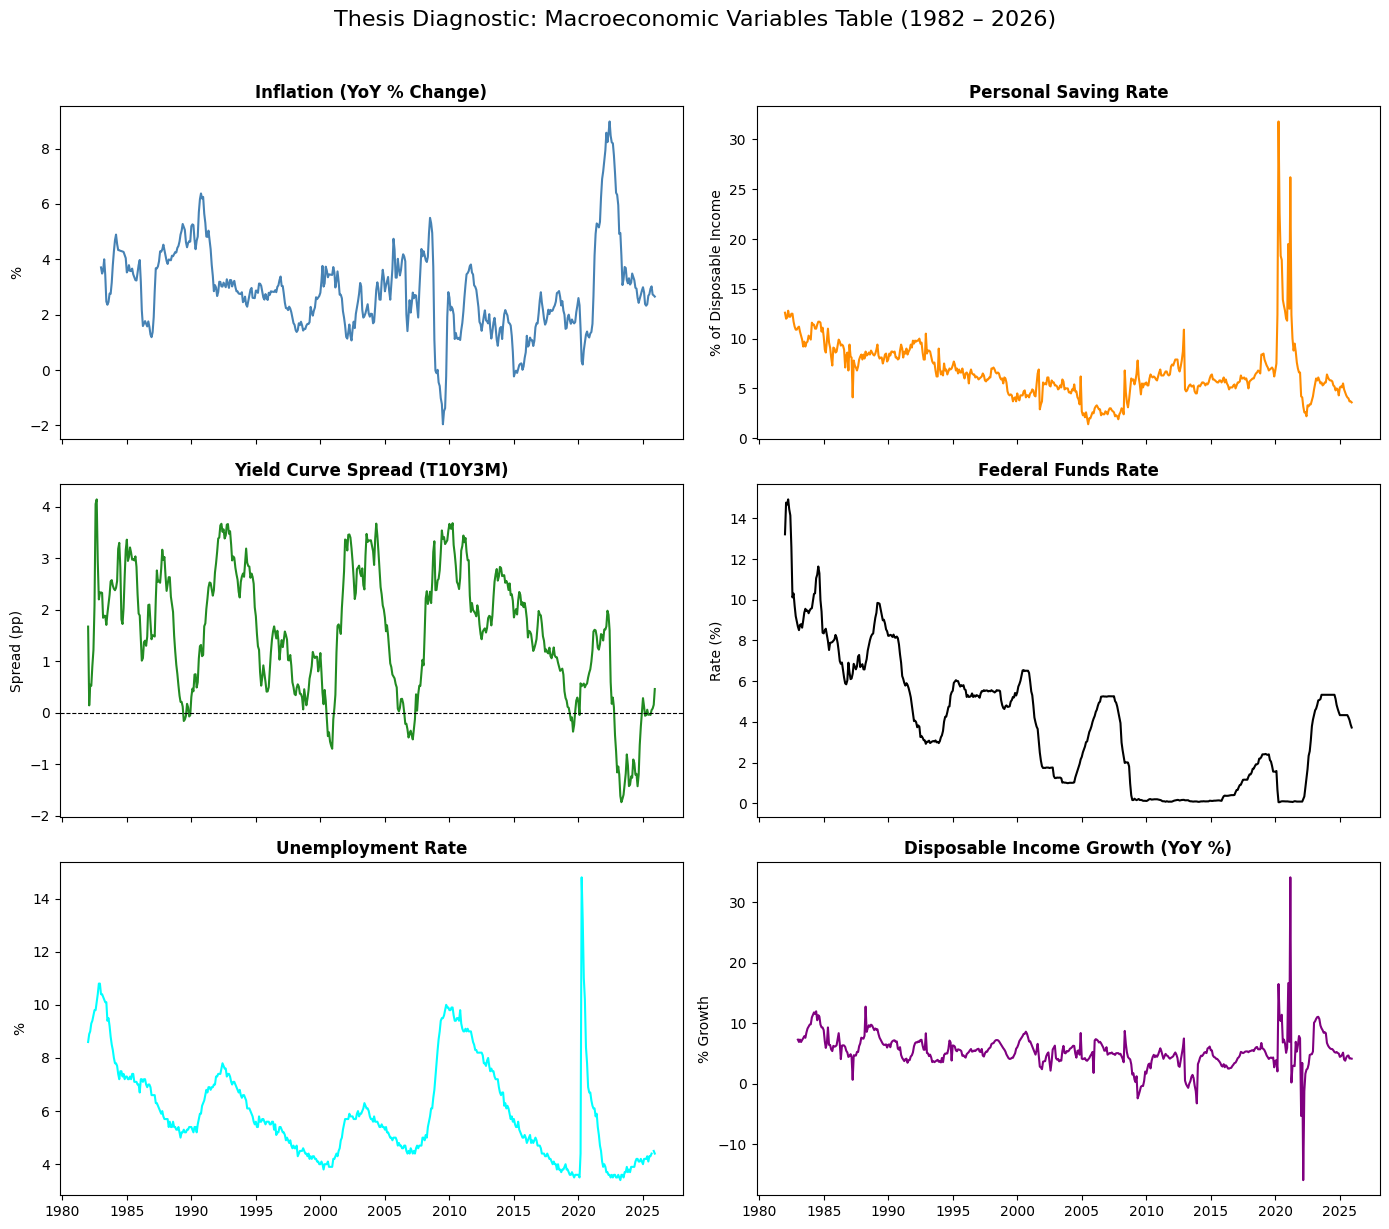

In [7]:
import matplotlib.pyplot as plt

# 1. Setup the 3x2 Grid
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
ax = axes.flatten()  # This turns the 3x2 matrix into a simple list of 6 items

# Row 1: Inflation & Savings
# Using % Change for CPI (Inflation) makes it a better diagnostic
ax[0].plot(df_final["observation_date"], df_final["CPIAUCSL"].pct_change(12)*100, color="steelblue")
ax[0].set_title("Inflation (YoY % Change)", fontweight="bold")
ax[0].set_ylabel("%")

ax[1].plot(df_final["observation_date"], df_final["PSAVERT"], color="darkorange")
ax[1].set_title("Personal Saving Rate", fontweight="bold")
ax[1].set_ylabel("% of Disposable Income")

# Row 2: Yield Curve & Fed Funds Rate
ax[2].plot(df_final["observation_date"], df_final["T10Y3M"], color="forestgreen")
ax[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
ax[2].set_title("Yield Curve Spread (T10Y3M)", fontweight="bold")
ax[2].set_ylabel("Spread (pp)")

ax[3].plot(df_final["observation_date"], df_final["DFF"], color="black")
ax[3].set_title("Federal Funds Rate", fontweight="bold")
ax[3].set_ylabel("Rate (%)")

# Row 3: Unemployment & Income Growth
ax[4].plot(df_final["observation_date"], df_final["UNRATE"], color="cyan")
ax[4].set_title("Unemployment Rate", fontweight="bold")
ax[4].set_ylabel("%")

# Using % Change for Income (Real-ish growth)
ax[5].plot(df_final["observation_date"], df_final["DSPI"].pct_change(12)*100, color="purple")
ax[5].set_title("Disposable Income Growth (YoY %)", fontweight="bold")
ax[5].set_ylabel("% Growth")

# Clean up layout
fig.suptitle("Thesis Diagnostic: Macroeconomic Variables Table (1982 – 2026)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Stationarity & Autocorrelation Checks

### 2.1 Transform CPI → Annualised Monthly Inflation Rate

The raw CPI is a **price level index** (baseline 1982–1984 = 100), not an inflation rate.
To convert it into a usable inflation series we apply three steps:

**Step 1 — Log difference** instead of a regular difference, because we care about *proportional* changes in prices, not absolute ones. A 10-point increase from 100 to 110 (10% inflation) is very different from a 10-point increase from 300 to 310 (3.3% inflation). The log difference handles this correctly:

$$\ln(CPI_t) - \ln(CPI_{t-1}) = \ln\left(\frac{CPI_t}{CPI_{t-1}}\right) \approx \text{monthly growth rate (decimal)}$$

**Step 2 — Multiply by 100** to convert the decimal into a percentage point (e.g. `0.003` → `0.3%`).

**Step 3 — Multiply by 12** to annualise the monthly rate, making it directly comparable to how inflation is reported in policy discussions and the news (e.g. the Fed's 2% annual target).

Steps 2 and 3 are combined into a single ×1200 factor:

$$\text{Inflation}_t = \left[\ln(CPI_t) - \ln(CPI_{t-1})\right] \times 1200$$

The resulting series can be interpreted as: *"if CPI kept growing at this month's rate for a full year, what would the annual inflation rate be?"*


Additionally, FFF and DSPI variables are "Integrated of Order 1" ($I(1)$), meaning they trend upward forever. Using them in levels leads to spurious regressions. Log-differencing makes them stationary ($I(0)$) and represents economic growth/inflation. --> DO THE COINTEGRATION TEST

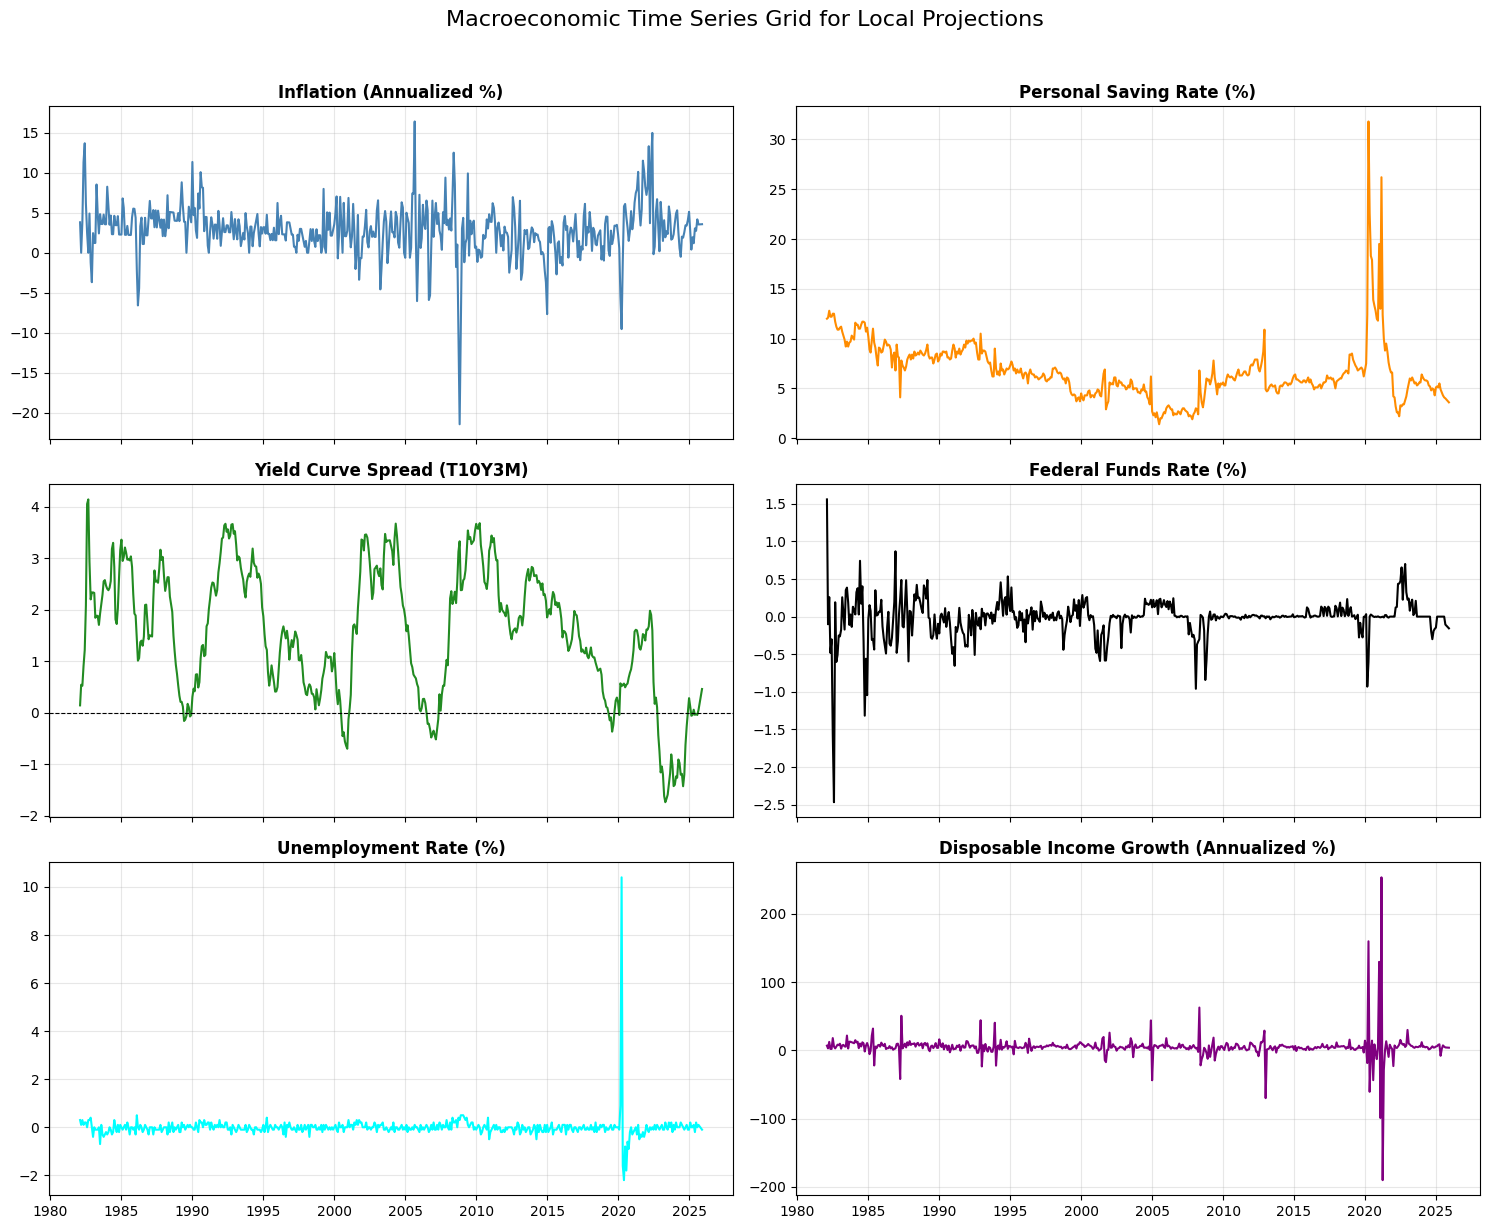

In [8]:
import numpy as np

# 1. Transform CPI to Inflation Rate (Log-Difference)
df_final["CPI"] = (np.log(df_final["CPIAUCSL"]) - np.log(df_final["CPIAUCSL"].shift(1))) * 1200

# 2. Transform DSPI to Growth Rate (Log-Difference)
# Same logic as Inflation: Annualized growth rate
df_final["DPI_Growth"] = (np.log(df_final["DSPI"]) - np.log(df_final["DSPI"].shift(1))) * 1200

# 3. Transform DFF and UNRATE (Optional: First Difference)
# While rates are already %, taking the difference (t - t-1)
# is standard for Local Projections to ensure the series is stationary.
df_final["d_DFF"] = df_final["DFF"].diff()
df_final["d_UNRATE"] = df_final["UNRATE"].diff()

# Clean up any NaNs created by shift/diff
df_final = df_final.dropna().reset_index(drop=True)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
ax = axes.flatten()

# Row 1: The Primary Variables
ax[0].plot(df_final["observation_date"], df_final["CPI"], color="steelblue")
ax[0].set_title("Inflation (Annualized %)", fontweight="bold")

ax[1].plot(df_final["observation_date"], df_final["PSAVERT"], color="darkorange")
ax[1].set_title("Personal Saving Rate (%)", fontweight="bold")

# Row 2: Monetary Policy & Yield Curve
ax[2].plot(df_final["observation_date"], df_final["T10Y3M"], color="forestgreen")
ax[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
ax[2].set_title("Yield Curve Spread (T10Y3M)", fontweight="bold")

ax[3].plot(df_final["observation_date"], df_final["d_DFF"], color="black")
ax[3].set_title("Federal Funds Rate (%)", fontweight="bold")

# Row 3: Labor Market & Real Income
ax[4].plot(df_final["observation_date"], df_final["d_UNRATE"], color="cyan")
ax[4].set_title("Unemployment Rate (%)", fontweight="bold")

ax[5].plot(df_final["observation_date"], df_final["DPI_Growth"], color="purple")
ax[5].set_title("Disposable Income Growth (Annualized %)", fontweight="bold")

# Formatting for thesis
for a in ax:
    a.grid(True, alpha=0.3)
    a.tick_params(labelsize=10)

fig.suptitle("Macroeconomic Time Series Grid for Local Projections", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Augmented Dickey-Fuller (ADF) Tests

**H₀:** Series has a unit root (non-stationary).  
Reject H₀ if the p-value < 0.05.

In [9]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, name, regression="c"):
    result = adfuller(series.dropna(), autolag="AIC", regression=regression)
    print(f"=== ADF Test: {name} ===")
    print(f"  Test Statistic : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.4f}")
    print(f"  Lags used      : {result[2]}")
    print(f"  Critical values: ", {k: f"{v:.3f}" for k, v in result[4].items()})
    conclusion = "Reject H₀ — stationary" if result[1] < 0.05 else "Fail to reject H₀ — non-stationary"
    print(f"  Conclusion     : {conclusion}\n")

# --- Original Variables ---
run_adf(df_final["CPI"], "Inflation", regression="c")
run_adf(df_final["PSAVERT"], "Personal Saving Rate", regression="c")
run_adf(df_final["T10Y3M"], "Yield Curve Spread", regression="n")

# --- New Control Variables ---
# Fed Funds Rate: Use 'c' for drift
run_adf(df_final["d_DFF"], "Federal Funds Rate", regression="c")

# Unemployment: Use 'c' for drift
run_adf(df_final["d_UNRATE"], "Unemployment Rate", regression="c")

# Disposable Income Growth: Use 'c' for drift (non-zero mean growth)
run_adf(df_final["DPI_Growth"], "DPI Growth (Log-Diff)", regression="c")

=== ADF Test: Inflation ===
  Test Statistic : -4.1145
  p-value        : 0.0009
  Lags used      : 14
  Critical values:  {'1%': '-3.443', '5%': '-2.867', '10%': '-2.570'}
  Conclusion     : Reject H₀ — stationary

=== ADF Test: Personal Saving Rate ===
  Test Statistic : -3.4604
  p-value        : 0.0091
  Lags used      : 13
  Critical values:  {'1%': '-3.443', '5%': '-2.867', '10%': '-2.570'}
  Conclusion     : Reject H₀ — stationary

=== ADF Test: Yield Curve Spread ===
  Test Statistic : -2.2204
  p-value        : 0.0254
  Lags used      : 9
  Critical values:  {'1%': '-2.570', '5%': '-1.942', '10%': '-1.616'}
  Conclusion     : Reject H₀ — stationary

=== ADF Test: Federal Funds Rate ===
  Test Statistic : -7.4231
  p-value        : 0.0000
  Lags used      : 4
  Critical values:  {'1%': '-3.443', '5%': '-2.867', '10%': '-2.570'}
  Conclusion     : Reject H₀ — stationary

=== ADF Test: Unemployment Rate ===
  Test Statistic : -13.2866
  p-value        : 0.0000
  Lags used      : 

All series reject H0, and thus are stationry!

### 2.3 ACF & PACF Plots

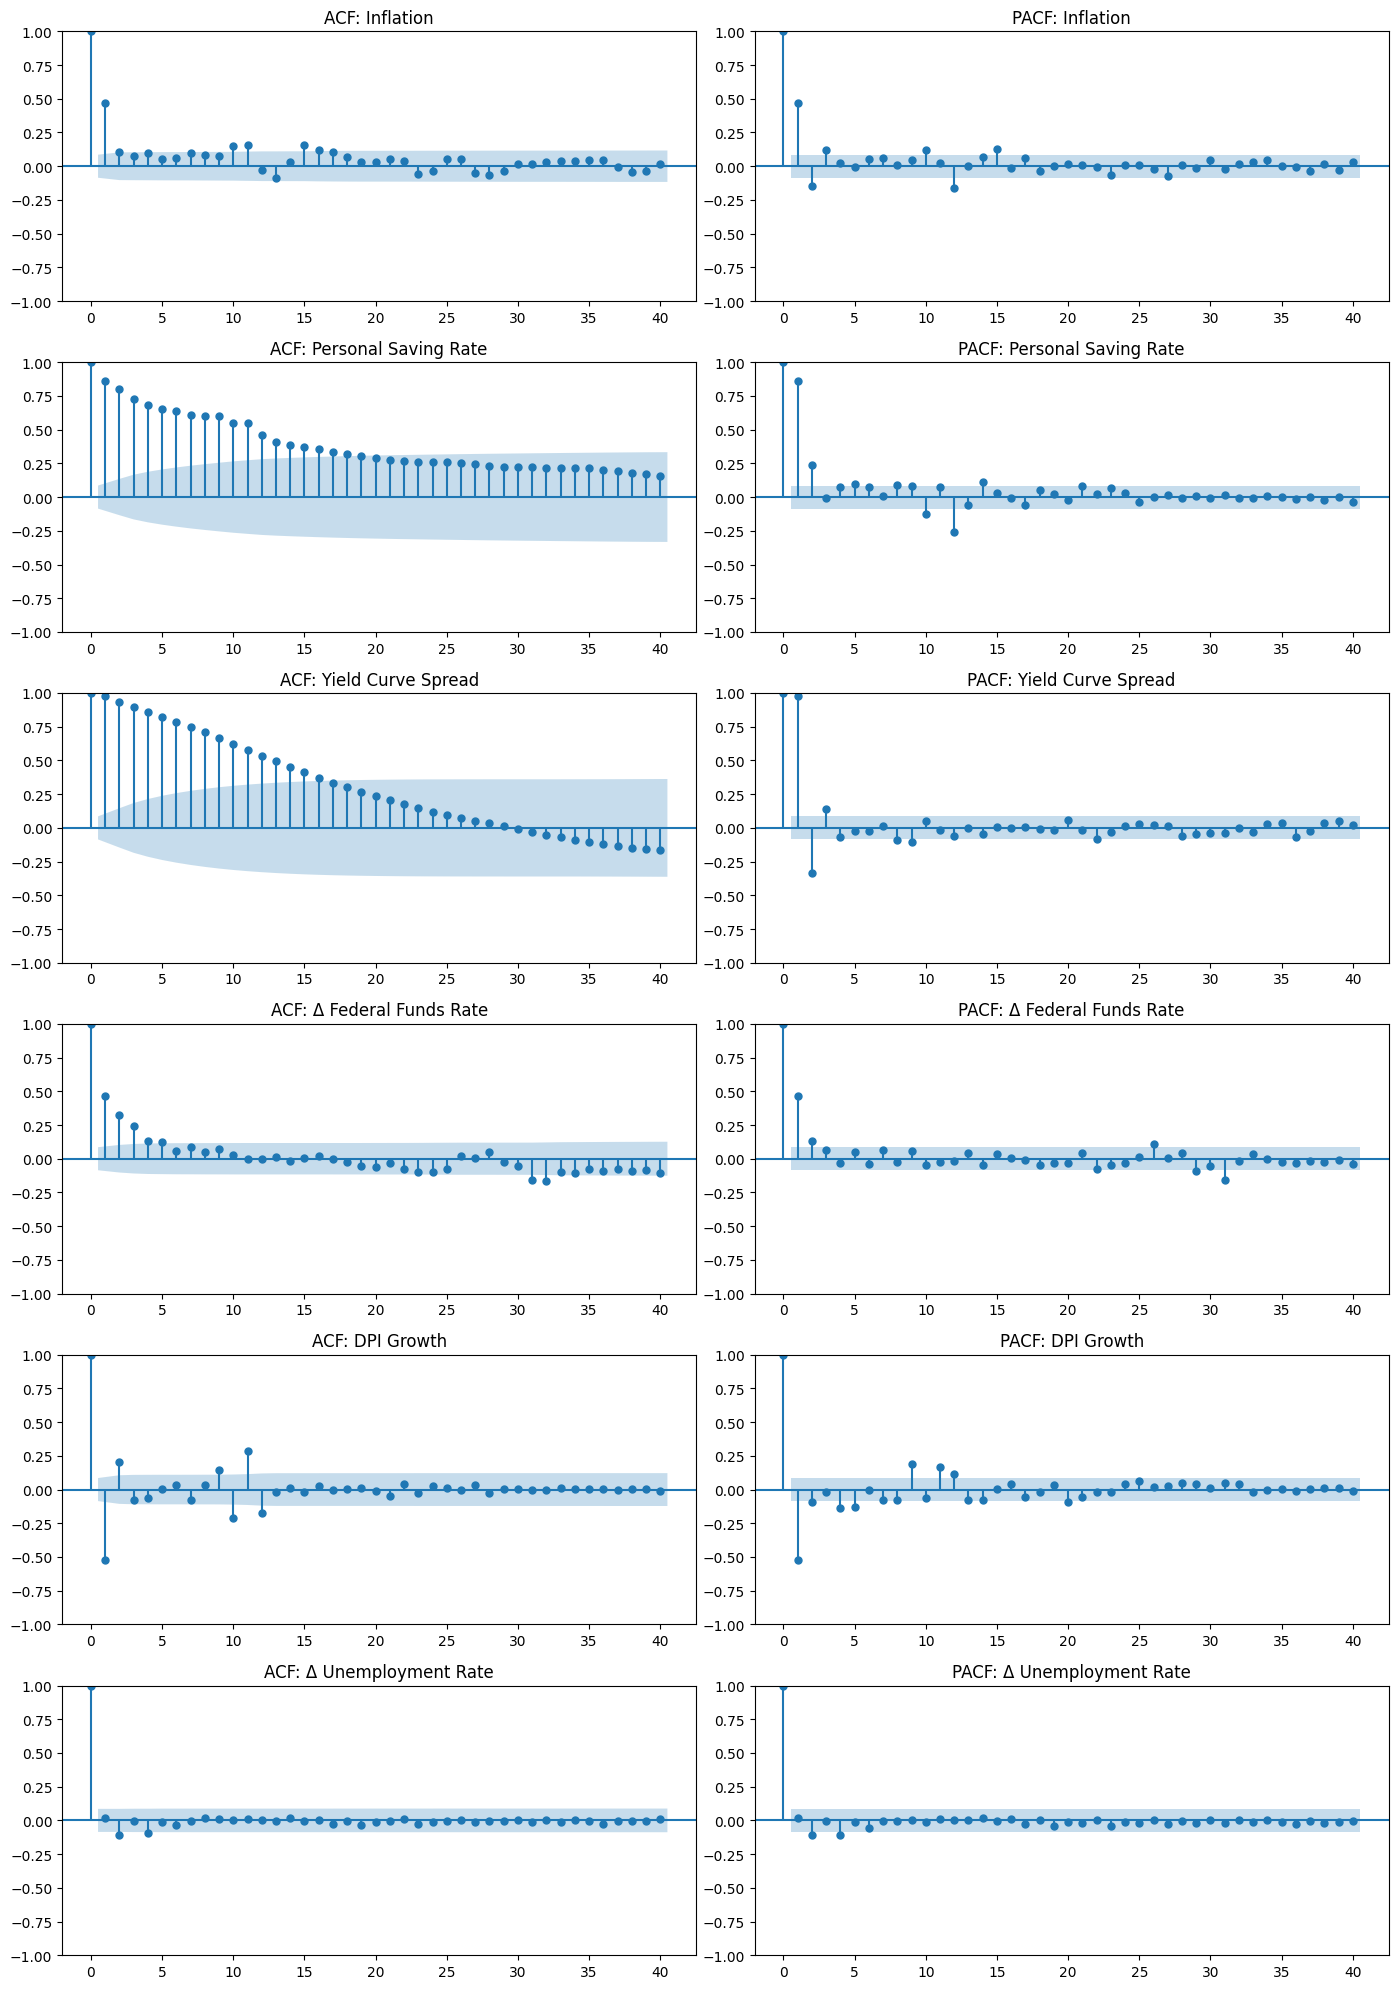

In [10]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Change to 6 rows to fit all 6 variables (ACF in col 1, PACF in col 2)
fig, axes = plt.subplots(6, 2, figsize=(14, 20))

series_list = [
    (df_final["CPI"],   "Inflation"),
    (df_final["PSAVERT"],     "Personal Saving Rate"),
    (df_final["T10Y3M"],      "Yield Curve Spread"),
    (df_final["d_DFF"],       "Δ Federal Funds Rate"),
    (df_final["DPI_Growth"],  "DPI Growth"), # Ensure you use the growth/stationary version
    (df_final["d_UNRATE"],    "Δ Unemployment Rate")
]

for i, (series, name) in enumerate(series_list):
    # Drop NaNs to avoid errors in ACF/PACF calculation
    clean_series = series.dropna()

    # axes[i, 0] is the left column (ACF)
    plot_acf(clean_series,  ax=axes[i, 0], lags=40, title=f"ACF: {name}")

    # axes[i, 1] is the right column (PACF)
    plot_pacf(clean_series, ax=axes[i, 1], lags=40, title=f"PACF: {name}")

plt.tight_layout()
plt.show()

Here we have some issues... We see that both the savings rate and the Yield Curve spread are highly persistent... We will address this.

## 3. Local Projections (Jordà 2005)

### 3.1 Setup & Lag Selection

The Local Projection estimator runs a separate OLS regression for each horizon
$h = 0, 1, \ldots, 24$:

$$PSAVERT_{t+h} - PSAVERT_{t-1} = \alpha^h + \beta^h \cdot SHOCK_t + \sum_{l=1}^{p} \gamma_l^h \mathbf{X}_{t-l} + \varepsilon_{t+h}$$

Where:
- The **left side** is the cumulative change in the saving rate between $t-1$ and $t+h$
- $SHOCK_t$ is either the **inversion dummy** (Experiment 1) or the **YC spread level** (Experiment 2)
- $\mathbf{X}_{t-l}$ are lags of all three variables (Inflation, PSAVERT, T10Y3M) included to control for persistence
- $\beta^h$ traced across all horizons gives the **impulse response function (IRF)**
- For Experiment 2, the IRF is scaled by $-10$ to reflect a 10pp decline in the yield curve

The number of lags $p$ is selected by minimising AIC on an VAR in levels.

In [11]:
##############################################################################
# 3.1  AIC/BIC-based lag selection (Updated with all controls)
##############################################################################
from statsmodels.tsa.api import VAR

# 1. Build the matrix of all stationary variables used in the LP
# We use the differenced versions for FFF, Unemployment, and Income
lp_vars = df_final[[
    "PSAVERT",      # Primary Dependent Variable
    "T10Y3M",       # Main Regressor
    "CPI",    # Control 1
    "d_DFF",        # Control 2 (Stationary change)
    "d_UNRATE",     # Control 3 (Stationary change)
    "DPI_Growth"    # Control 4 (Stationary growth)
]].copy()

# 2. Drop any NaNs created by transformations/shifting
lp_vars = lp_vars.dropna()

# 3. Fit VAR and select lag order
# Maxlags=12 is standard for monthly macro data to catch annual seasonality
var_model = VAR(lp_vars)
lag_selection = var_model.select_order(maxlags=12)

# 4. Extract p-values for different criteria
p_aic = lag_selection.aic
p_bic = lag_selection.bic

print(f"AIC-selected lag order: p = {p_aic}")
print(f"BIC-selected lag order: p = {p_bic}")
print("-" * 30)
print(lag_selection.summary())

AIC-selected lag order: p = 12
BIC-selected lag order: p = 2
------------------------------
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        6.011       6.061       407.9       6.031
1       -1.773      -1.426      0.1698      -1.637
2       -2.135     -1.491*      0.1182     -1.883*
3       -2.246      -1.304      0.1058      -1.877
4       -2.179     -0.9394      0.1132      -1.693
5       -2.140     -0.6021      0.1178      -1.537
6       -2.089     -0.2540      0.1240      -1.370
7       -2.073     0.05910      0.1261      -1.238
8       -2.012      0.4177      0.1341      -1.060
9       -2.004      0.7239      0.1355     -0.9346
10      -2.014       1.011      0.1343     -0.8287
11      -2.655      0.6682     0.07097      -1.352
12     -2.684*      0.9368    0.06912*      -1.264
--------------------------------------------------


### 3.2 Build the Regression Dataset

#### 3.2.1. Adding recession dummies

In [12]:
# NBER recession months — add this to df_lp
# Download from FRED: USREC
recession = pd.read_csv(data_path + "/USREC.csv")
recession["observation_date"] = pd.to_datetime(recession["observation_date"])

In [13]:
##############################################################################
# 3.2 Construct LP dataset (Full Model with 6 Variables)
##############################################################################

H = 24  # maximum horizon

# 1. Initialize with core and new stationary variables (excluding USREC for now)
cols_to_keep = [
    "observation_date", "CPI", "PSAVERT", "T10Y3M",
    "d_DFF", "d_UNRATE", "DPI_Growth"
]
df_lp = df_final[cols_to_keep].copy()

# --- Experiment 1: Inversion dummy ---
df_lp["D_inversion"] = (df_lp["T10Y3M"] < 0).astype(int)

# --- Dummies: COVID and Recession ---
df_lp["D_covid"] = ((df_lp["observation_date"] >= "2020-03-01") &
                    (df_lp["observation_date"] <= "2021-06-01")).astype(int)

# Merge recession data into df_lp (defined in cell 6DLdL0V02doD)
df_lp = df_lp.merge(recession[['observation_date', 'USREC']], on="observation_date", how="left")
df_lp.rename(columns={"USREC": "D_recession"}, inplace=True)

# Fill NaNs created by merge (periods outside NBER recession) with 0
df_lp["D_recession"] = df_lp["D_recession"].fillna(0).astype(int)

# --- Lag matrix: p lags of ALL variables ---

# This ensures we control for the past dynamics of the entire system
vars_to_lag = ["CPI", "PSAVERT", "T10Y3M", "d_DFF", "d_UNRATE", "DPI_Growth"]

for lag in range(1, p_bic + 1):
    for var in vars_to_lag:
        df_lp[f"{var}_L{lag}"] = df_lp[var].shift(lag)

# --- Outcome variables: cumulative change in PSAVERT at each horizon h ---
# PSAVERT_{t+h} - PSAVERT_{t-1}
df_lp["PSAVERT_Lminus1"] = df_lp["PSAVERT"].shift(1)

for h in range(0, H + 1):
    # This captures the change from the month PRIOR to the shock (t-1) to the horizon (t+h)
    df_lp[f"y_h{h}"] = df_lp["PSAVERT"].shift(-h) - df_lp["PSAVERT_Lminus1"]

# Drop NaNs created by lags (at the start) and horizons (at the end)
df_lp = df_lp.dropna().reset_index(drop=True)

print(f"LP dataset shape after dropping NAs: {df_lp.shape}")
print(f"Lags used (p): {p_bic}")
df_lp.head()

LP dataset shape after dropping NAs: (499, 48)
Lags used (p): 2


,observation_date,CPI,PSAVERT,T10Y3M,d_DFF,d_UNRATE,DPI_Growth,D_inversion,D_covid,D_recession,...,y_h15,y_h16,y_h17,y_h18,y_h19,y_h20,y_h21,y_h22,y_h23,y_h24
0,1982-04-01,3.795470,12.8,0.527143,0.259258,0.3,12.486270,0,0,1,...,-2.4,-2.9,-2.5,-2.4,-1.8,-2.0,-2.2,-0.5,-0.7,-0.7
1,1982-05-01,11.314908,12.2,0.908500,-0.482161,0.1,2.143169,0,0,1,...,-3.6,-3.2,-3.1,-2.5,-2.7,-2.9,-1.2,-1.4,-1.4,-1.8
2,1982-06-01,13.685996,12.2,1.220909,-0.302172,0.2,2.139348,0,0,1,...,-2.6,-2.5,-1.9,-2.1,-2.3,-0.6,-0.8,-0.8,-1.2,-1.2
3,1982-07-01,6.169679,12.5,2.082857,-1.565892,0.2,18.007615,0,0,1,...,-2.5,-1.9,-2.1,-2.3,-0.6,-0.8,-0.8,-1.2,-1.2,-0.8
4,1982-08-01,2.459017,12.5,4.057727,-2.467742,0.0,5.666840,0,0,1,...,-2.2,-2.4,-2.6,-0.9,-1.1,-1.1,-1.5,-1.5,-1.1,-0.8


### 3.3 Run Local Projections

In [14]:
import statsmodels.api as sm

##############################################################################
# 3.3  Local Projection regressions — Updated with full controls
##############################################################################

# 1. Update lag_cols to include the 3 new variables
lag_cols = []
vars_to_lag = ["CPI", "PSAVERT", "T10Y3M", "d_DFF", "d_UNRATE", "DPI_Growth"]

for l in range(1, p_bic + 1):
    for var in vars_to_lag:
        lag_cols.append(f"{var}_L{l}")

# 2. Define Contemporary Controls (Slow variables: PSAVERT, Inflation, UNRATE, Income)
# We assume these do not react to the Yield Curve within the same month
contemp_controls = ["PSAVERT", "CPI", "d_UNRATE", "DPI_Growth"]

# 3. Define Policy & Outlier Controls
# d_DFF is included here as a contemporaneous control if we assume
# the Fed reacts to the economy faster than the economy reacts to the Fed.
policy_controls = ["d_DFF"]
outlier_controls = ["D_covid", "D_recession"]

# Create the pre-2020 dataset
df_lp_pre2020 = df_lp.query("observation_date < '2020-01-01'").copy()
# Remove D_covid column if it exists in the pre-2020 data as it won't be relevant
if "D_covid" in df_lp_pre2020.columns: # Check if column exists
    df_lp_pre2020 = df_lp_pre2020.drop(columns=["D_covid"])

# --- Helper function to run LP for a given dataset and SE type ---
def run_lp_model(data, se_type, H=H):
    results_exp1_model = []
    results_exp2_model = []

    # Controls available in the current dataset (df_lp_pre2020 might not have D_covid)
    avail_outlier_controls = [c for c in outlier_controls if c in data.columns]

    for h in range(0, H + 1):
        y = data[f"y_h{h}"]

        if se_type == "HC1":
            fit_kwargs = {"cov_type": "HC1"}
        else: # Newey-West (HAC)
            # Maxlags for HAC should be related to the number of horizons
            fit_kwargs = {"cov_type": "HAC", "cov_kwds": {"maxlags": 8}} # Adjust maxlags to be at most h+1 for robustness

        # --- Experiment 1: Inversion dummy ---
        cols1 = ["D_inversion"] + contemp_controls + policy_controls + avail_outlier_controls + lag_cols
        # Filter columns that actually exist in the dataframe
        cols1 = [c for c in cols1 if c in data.columns]
        X1 = sm.add_constant(data[cols1])

        model1 = sm.OLS(y, X1).fit(**fit_kwargs)
        coef1 = model1.params["D_inversion"]
        # Need p-value for make_latex_irf_table later
        pval1 = model1.pvalues["D_inversion"]
        ci1 = model1.conf_int(alpha=0.10).loc["D_inversion"]
        results_exp1_model.append({"h": h, "coef": coef1, "ci_low": ci1[0], "ci_high": ci1[1], "pval": pval1, "model": model1})

        # --- Experiment 2: 1pp decline in YC Spread ---
        cols2 = ["T10Y3M"] + contemp_controls + policy_controls + avail_outlier_controls + lag_cols
        # Filter columns that actually exist in the dataframe
        cols2 = [c for c in cols2 if c in data.columns]
        X2 = sm.add_constant(data[cols2])

        model2 = sm.OLS(y, X2).fit(**fit_kwargs)
        coef2 = model2.params["T10Y3M"]
        # Need p-value for make_latex_irf_table later
        pval2 = model2.pvalues["T10Y3M"]
        ci2 = model2.conf_int(alpha=0.10).loc["T10Y3M"]

        # Scale by -1 for a 1 percentage point decline
        shock_size = -1
        results_exp2_model.append({
            "h": h,
            "coef": coef2 * shock_size,
            "ci_low": min(ci2[0] * shock_size, ci2[1] * shock_size), # Ensure low/high are correct after scaling by negative
            "ci_high": max(ci2[0] * shock_size, ci2[1] * shock_size),
            "pval": pval2, "model": model2
        })
    return pd.DataFrame(results_exp1_model), pd.DataFrame(results_exp2_model), [r["model"] for r in results_exp1_model], [r["model"] for r in results_exp2_model]

# --- Run all four models ---
print("Running Model 1 (HC1, Full Sample)...")
irf1_m1, irf2_m1, mods1_m1, mods2_m1 = run_lp_model(df_lp, "HC1")

print("Running Model 2 (HC1, Pre-2020)...")
irf1_m2, irf2_m2, mods1_m2, mods2_m2 = run_lp_model(df_lp_pre2020, "HC1")

print("Running Model 3 (Newey-West, Full Sample)...")
irf1_m3, irf2_m3, mods1_m3, mods2_m3 = run_lp_model(df_lp, "HAC")

print("Running Model 4 (Newey-West, Pre-2020)...")
irf1_m4, irf2_m4, mods1_m4, mods2_m4 = run_lp_model(df_lp_pre2020, "HAC")

print("All four models estimated successfully.")
print("Experiment 1 (Inversion) Model 1 Head:")
print(irf1_m1.head())


Running Model 1 (HC1, Full Sample)...
Running Model 2 (HC1, Pre-2020)...
Running Model 3 (Newey-West, Full Sample)...
Running Model 4 (Newey-West, Pre-2020)...
All four models estimated successfully.
Experiment 1 (Inversion) Model 1 Head:
   h          coef        ci_low       ci_high      pval  \
0  0  3.760013e-15  1.650093e-16  7.355017e-15  0.085369   
1  1  1.292143e-01 -1.804159e-01  4.388444e-01  0.492444   
2  2  7.714519e-01 -3.928405e-01  1.935744e+00  0.275771   
3  3  3.742204e-01 -5.249372e-01  1.273378e+00  0.493614   
4  4  8.407192e-02 -7.271295e-01  8.952733e-01  0.864640   

                                               model  
0  <statsmodels.regression.linear_model.Regressio...  
1  <statsmodels.regression.linear_model.Regressio...  
2  <statsmodels.regression.linear_model.Regressio...  
3  <statsmodels.regression.linear_model.Regressio...  
4  <statsmodels.regression.linear_model.Regressio...  


### 3.4 Plot Impulse Response Functions

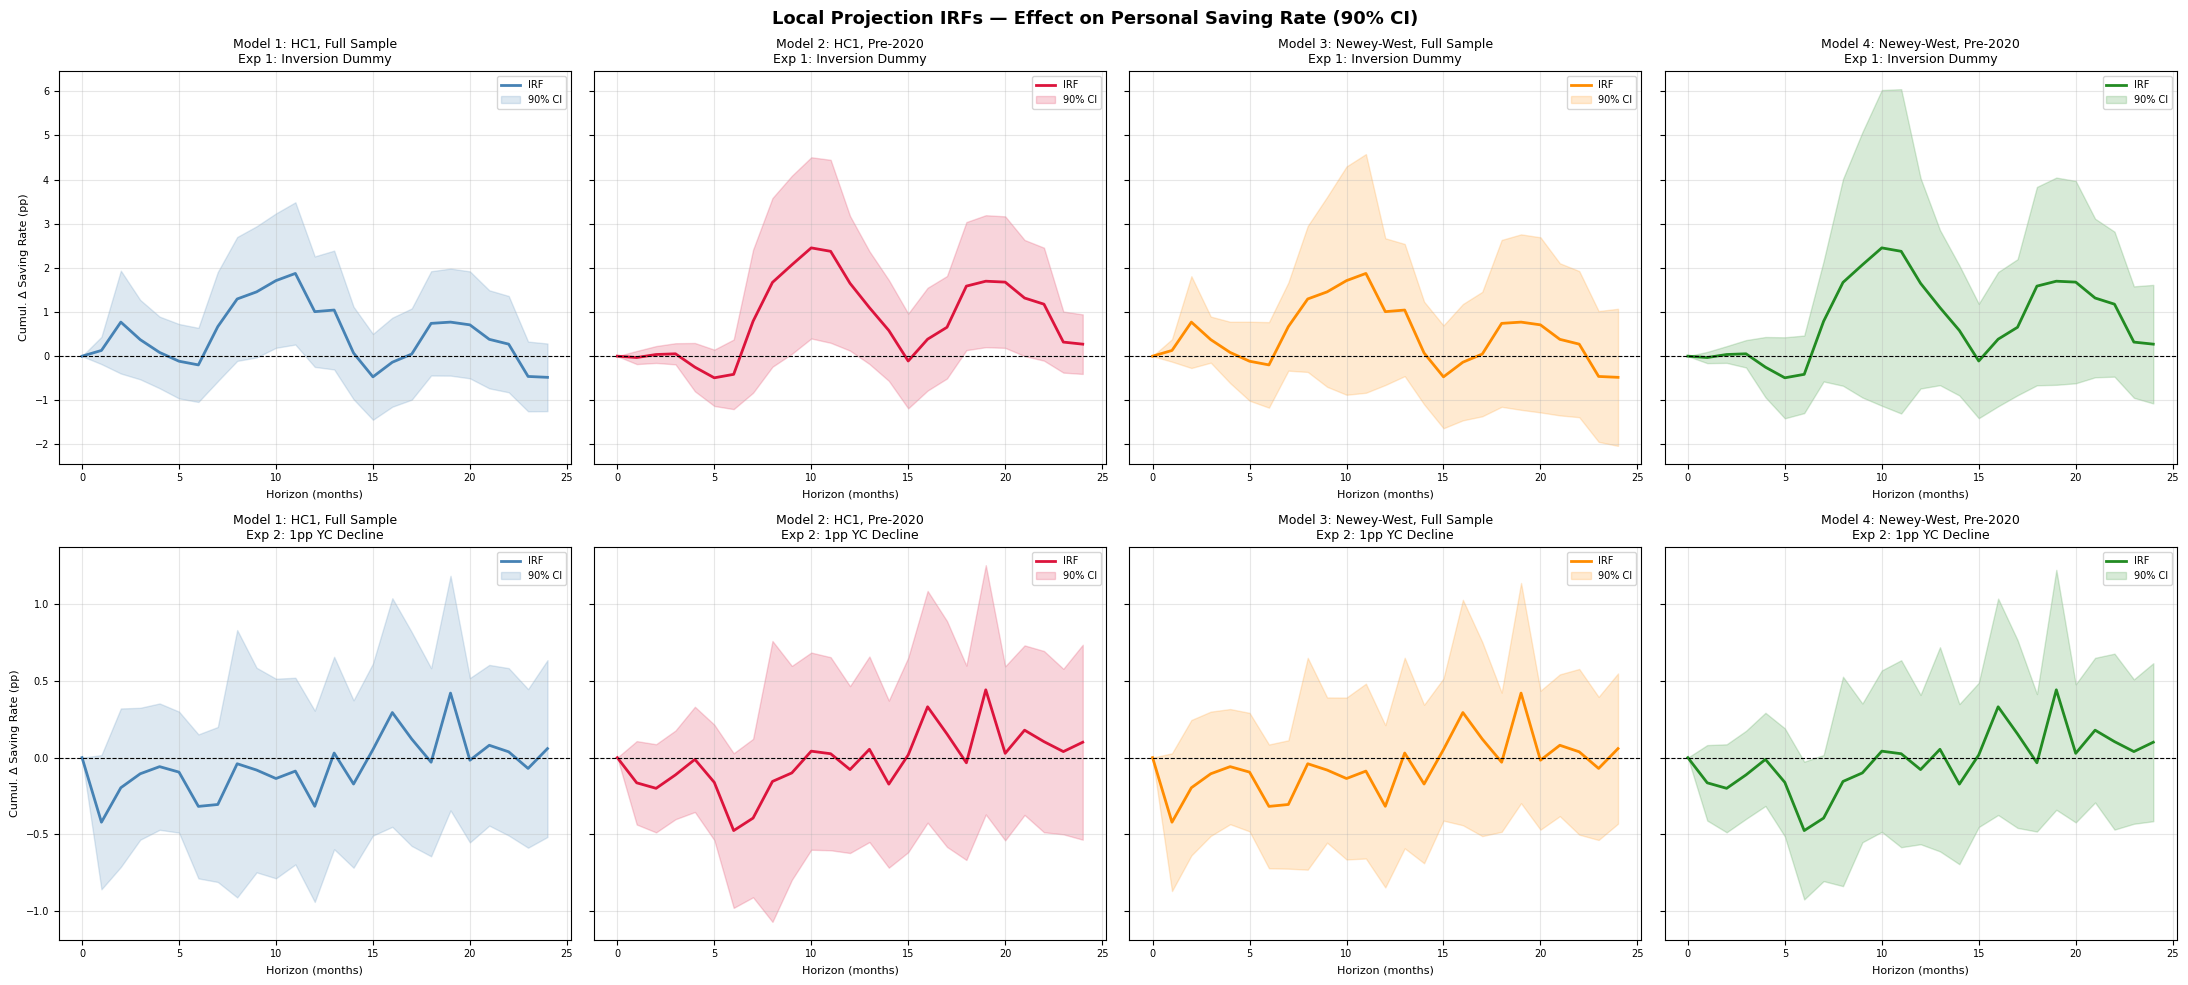


  Experiment 1: Yield Curve Inversion (Dummy)
  Columns: coef = point estimate | ci_low / ci_high = 90% CI bounds
         M1 coef  M1 ci_low  M1 ci_high  M2 coef  M2 ci_low  M2 ci_high  M3 coef  M3 ci_low  M3 ci_high  M4 coef  M4 ci_low  M4 ci_high
Horizon                                                                                                                                
0          0.000      0.000       0.000   -0.000     -0.000       0.000    0.000     -0.000       0.000   -0.000     -0.000       0.000
1          0.129     -0.180       0.439   -0.031     -0.179       0.117    0.129     -0.125       0.384   -0.031     -0.158       0.096
2          0.771     -0.393       1.936    0.038     -0.154       0.229    0.771     -0.268       1.811    0.038     -0.152       0.227
3          0.374     -0.525       1.273    0.054     -0.186       0.293    0.374     -0.148       0.896    0.054     -0.257       0.364
4          0.084     -0.727       0.895   -0.249     -0.796       0.2

In [15]:
# 3.7  IRF Plots — one figure per model, and summary tables

model_names = [
    "Model 1: HC1, Full Sample",
    "Model 2: HC1, Pre-2020",
    "Model 3: Newey-West, Full Sample",
    "Model 4: Newey-West, Pre-2020",
]

irfs_exp1 = [irf1_m1, irf1_m2, irf1_m3, irf1_m4]
irfs_exp2 = [irf2_m1, irf2_m2, irf2_m3, irf2_m4]

colors = ["steelblue", "crimson", "darkorange", "forestgreen"]

# --- IRF plots: 2 rows (one per experiment) x 4 cols (one per model) ---
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey="row")

for col, (m_name, color) in enumerate(zip(model_names, colors)):
    for row, (irfs, exp_label) in enumerate([
        (irfs_exp1, "Exp 1: Inversion Dummy"),
        (irfs_exp2, "Exp 2: 1pp YC Decline"),
    ]):
        ax  = axes[row, col]
        irf = irfs[col]

        ax.plot(irf["h"], irf["coef"], color=color, linewidth=2, label="IRF")
        ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"],
                        alpha=0.18, color=color, label="90% CI")
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_title(f"{m_name}\n{exp_label}", fontsize=9)
        ax.set_xlabel("Horizon (months)", fontsize=8)
        if col == 0:
            ax.set_ylabel("Cumul. \u0394 Saving Rate (pp)", fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

plt.suptitle("Local Projection IRFs — Effect on Personal Saving Rate (90% CI)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


##############################################################################
# 3.8  Summary Tables — IRF Coefficients and CIs for all models
##############################################################################

def make_summary_table(irfs, model_names, experiment_name):
    """
    Combines IRF results from all models into one table.
    For each horizon h, shows coef, ci_low, ci_high for every model.
    """
    rows = []
    for h in range(len(irfs[0])):
        row = {"Horizon": h}
        for irf, name in zip(irfs, model_names):
            short = name.replace("Model ", "M").split(":")[0].strip()
            row[f"{short} coef"]    = round(irf.loc[h, "coef"],    3)
            row[f"{short} ci_low"]  = round(irf.loc[h, "ci_low"],  3)
            row[f"{short} ci_high"] = round(irf.loc[h, "ci_high"], 3)
        rows.append(row)

    df = pd.DataFrame(rows).set_index("Horizon")

    print(f"\n{'='*80}")
    print(f"  {experiment_name}")
    print(f"  Columns: coef = point estimate | ci_low / ci_high = 90% CI bounds")
    print(f"{'='*80}")
    print(df.to_string())
    return df


table_exp1 = make_summary_table(
    irfs            = irfs_exp1,
    model_names     = model_names,
    experiment_name = "Experiment 1: Yield Curve Inversion (Dummy)"
)

table_exp2 = make_summary_table(
    irfs            = irfs_exp2,
    model_names     = model_names,
    experiment_name = "Experiment 2: 1pp Decline in Yield Curve Spread"
)


In [16]:
##############################################################################
# 3.9  Joint Chi-Squared Test — Lean Spec, All Four Models
#
# Tests H0: beta^h = 0 for ALL h = 1, ..., 24 simultaneously.
#
# Method: chi2 = sum of z^2 where z = coef / SE
#         SE back-calculated from 90% CI: SE = (ci_high - ci_low) / (2 * 1.645)
# Under H0 this is distributed chi2(24).
#
# h=0 excluded — Cholesky ordering makes beta^0 = 0 by construction.
##############################################################################

from scipy import stats

H_test = 24

def pval_stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

def joint_chi2_test(irf, model_name, experiment_name, H_test=24):
    subset = irf[irf["h"].between(1, H_test)].copy()

    # Back out SE from 90% CI: SE = (ci_high - ci_low) / (2 * z_0.05)
    subset["se"]     = (subset["ci_high"] - subset["ci_low"]) / (2 * 1.6449)
    subset["z_stat"] = subset["coef"] / subset["se"]
    subset["pval_z"] = 2 * (1 - stats.norm.cdf(abs(subset["z_stat"])))

    chi2    = (subset["z_stat"] ** 2).sum()
    df      = len(subset)
    p_joint = stats.chi2.sf(chi2, df=df)

    print(f"\n  {model_name} | {experiment_name}")
    print(f"  {'─'*60}")
    print(f"  Horizons tested    : h = 1 to {H_test}  (n = {df})")
    print(f"  Chi2 statistic     : {chi2:.3f}")
    print(f"  Degrees of freedom : {df}")
    print(f"  Joint p-value      : {p_joint:.4f} {pval_stars(p_joint)}")

    top3 = subset.nsmallest(3, "pval_z")[["h", "coef", "se", "pval_z"]].copy()
    top3.columns = ["h", "coef", "se", "pval"]
    print(f"  Top 3 horizons     :")
    print(top3.to_string(index=False))

    return {"model": model_name, "experiment": experiment_name,
            "chi2": round(chi2, 3), "df": df,
            "p_joint": round(p_joint, 4), "stars": pval_stars(p_joint)}


# --- Run for all four models x two experiments ---
print("=" * 70)
print("  JOINT CHI-SQUARED TESTS — Lean Spec (h=1 to 24)")
print("=" * 70)

joint_results = []

for irf, m_name in [
    (irf1_m1, "Model 1: HC1, Full"),
    (irf1_m2, "Model 2: HC1, Pre-2020"),
    (irf1_m3, "Model 3: HAC, Full"),
    (irf1_m4, "Model 4: HAC, Pre-2020"),
]:
    joint_results.append(joint_chi2_test(irf, m_name, "Exp 1: Inversion Dummy"))

print()

for irf, m_name in [
    (irf2_m1, "Model 1: HC1, Full"),
    (irf2_m2, "Model 2: HC1, Pre-2020"),
    (irf2_m3, "Model 3: HAC, Full"),
    (irf2_m4, "Model 4: HAC, Pre-2020"),
]:
    joint_results.append(joint_chi2_test(irf, m_name, "Exp 2: 1pp YC Decline"))


# --- Summary pivot table ---
print(f"\n\n{'='*70}")
print("  JOINT TEST SUMMARY")
print(f"  H0: beta^h = 0 for all h = 1,...,24")
print(f"  * p<0.10  ** p<0.05  *** p<0.01")
print(f"{'='*70}")

summary_df = pd.DataFrame(joint_results)
summary_df["result"] = summary_df.apply(
    lambda r: f"chi2={r['chi2']:.2f}, p={r['p_joint']:.4f}{r['stars']}", axis=1
)
pivot = summary_df.pivot(index="model", columns="experiment", values="result")
print(pivot.to_string())

  JOINT CHI-SQUARED TESTS — Lean Spec (h=1 to 24)

  Model 1: HC1, Full | Exp 1: Inversion Dummy
  ────────────────────────────────────────────────────────────
  Horizons tested    : h = 1 to 24  (n = 24)
  Chi2 statistic     : 24.778
  Degrees of freedom : 24
  Joint p-value      : 0.4179 
  Top 3 horizons     :
 h     coef       se     pval
11 1.873742 0.979296 0.055703
10 1.711022 0.925122 0.064384
 9 1.456295 0.902838 0.106740

  Model 2: HC1, Pre-2020 | Exp 1: Inversion Dummy
  ────────────────────────────────────────────────────────────
  Horizons tested    : h = 1 to 24  (n = 24)
  Chi2 statistic     : 39.477
  Degrees of freedom : 24
  Joint p-value      : 0.0243 **
  Top 3 horizons     :
 h     coef       se     pval
10 2.452438 1.247672 0.049344
11 2.374598 1.259783 0.059440
19 1.697717 0.908534 0.061674

  Model 3: HAC, Full | Exp 1: Inversion Dummy
  ────────────────────────────────────────────────────────────
  Horizons tested    : h = 1 to 24  (n = 24)
  Chi2 statistic   

### 3.5 Reduce controls

In [17]:
import statsmodels.api as sm

##############################################################################
# 3.5  Local Projection regressions — Lean spec, four model variants
#
# Results stored in *_lean variables to avoid overwriting full-control results
#
# Dropped vs full spec:
#   - d_DFF (lags + contemporaneous)
#   - DPI_Growth (contemporaneous)
#
# Remaining controls:
#   Lags     : CPI, PSAVERT, T10Y3M, d_UNRATE  (p_bic lags each)
#   Contemp. : PSAVERT, CPI, d_UNRATE
#   Outliers : D_covid, D_recession
#
# Model 1: HC1 SEs,        full sample
# Model 2: HC1 SEs,        pre-2020
# Model 3: Newey-West SEs, full sample
# Model 4: Newey-West SEs, pre-2020
##############################################################################

# --- Lag columns ---
lag_cols_lean = []
vars_to_lag_lean = ["CPI", "PSAVERT", "T10Y3M", "d_UNRATE"]
for l in range(1, p_bic + 1):
    for var in vars_to_lag_lean:
        lag_cols_lean.append(f"{var}_L{l}")

# --- Control groups ---
contemp_controls_lean = ["PSAVERT", "CPI", "d_UNRATE"]
outlier_controls_lean = ["D_covid", "D_recession"]

print(f"Lean spec — lag columns ({len(lag_cols_lean)}): {lag_cols_lean}")
print(f"Full sample:     {len(df_lp)} observations")
print(f"Pre-2020 sample: {len(df_lp_pre2020)} observations")


# --- Helper ---
def run_lp_lean(data, se_type, H=H):
    res1, res2 = [], []
    avail_outlier = [c for c in outlier_controls_lean if c in data.columns]

    for h in range(0, H + 1):
        y = data[f"y_h{h}"]

        if se_type == "HC1":
            fit_kwargs = {"cov_type": "HC1"}
        else:
            fit_kwargs = {"cov_type": "HAC", "cov_kwds": {"maxlags": 8}} # or adjust to h + 1

        # Experiment 1: Inversion dummy
        cols1 = [c for c in ["D_inversion"] + contemp_controls_lean + avail_outlier + lag_cols_lean
                 if c in data.columns]
        m1  = sm.OLS(y, sm.add_constant(data[cols1])).fit(**fit_kwargs)
        ci1 = m1.conf_int(alpha=0.10).loc["D_inversion"]
        res1.append({"h": h, "coef": m1.params["D_inversion"],
                     "ci_low": ci1[0], "ci_high": ci1[1]})

        # Experiment 2: 1pp decline in YC spread
        cols2 = [c for c in ["T10Y3M"] + contemp_controls_lean + avail_outlier + lag_cols_lean
                 if c in data.columns]
        m2    = sm.OLS(y, sm.add_constant(data[cols2])).fit(**fit_kwargs)
        coef2 = m2.params["T10Y3M"]
        ci2   = m2.conf_int(alpha=0.10).loc["T10Y3M"]
        shock = -1
        res2.append({"h": h,
                     "coef":    coef2  * shock,
                     "ci_low":  min(ci2[0] * shock, ci2[1] * shock),
                     "ci_high": max(ci2[0] * shock, ci2[1] * shock)})

    return pd.DataFrame(res1), pd.DataFrame(res2)


# --- Run all four models (lean) ---
print("\nRunning Model 1 lean (HC1, Full)...")
irf1_m1_lean, irf2_m1_lean = run_lp_lean(df_lp,         "HC1")

print("Running Model 2 lean (HC1, Pre-2020)...")
irf1_m2_lean, irf2_m2_lean = run_lp_lean(df_lp_pre2020, "HC1")

print("Running Model 3 lean (Newey-West, Full)...")
irf1_m3_lean, irf2_m3_lean = run_lp_lean(df_lp,         "HAC")

print("Running Model 4 lean (Newey-West, Pre-2020)...")
irf1_m4_lean, irf2_m4_lean = run_lp_lean(df_lp_pre2020, "HAC")

print("\nAll four lean models estimated successfully.")
print("\nModel 1 lean — Experiment 1 (head):")
print(irf1_m1_lean.head())

Lean spec — lag columns (8): ['CPI_L1', 'PSAVERT_L1', 'T10Y3M_L1', 'd_UNRATE_L1', 'CPI_L2', 'PSAVERT_L2', 'T10Y3M_L2', 'd_UNRATE_L2']
Full sample:     499 observations
Pre-2020 sample: 453 observations

Running Model 1 lean (HC1, Full)...
Running Model 2 lean (HC1, Pre-2020)...
Running Model 3 lean (Newey-West, Full)...
Running Model 4 lean (Newey-West, Pre-2020)...

All four lean models estimated successfully.

Model 1 lean — Experiment 1 (head):
   h          coef        ci_low       ci_high
0  0 -1.401223e-15 -1.995340e-15 -8.071062e-16
1  1  3.882027e-02 -3.149751e-01  3.926157e-01
2  2  7.045935e-01 -4.773143e-01  1.886501e+00
3  3  3.061808e-01 -6.024905e-01  1.214852e+00
4  4  1.705260e-02 -8.010829e-01  8.351882e-01


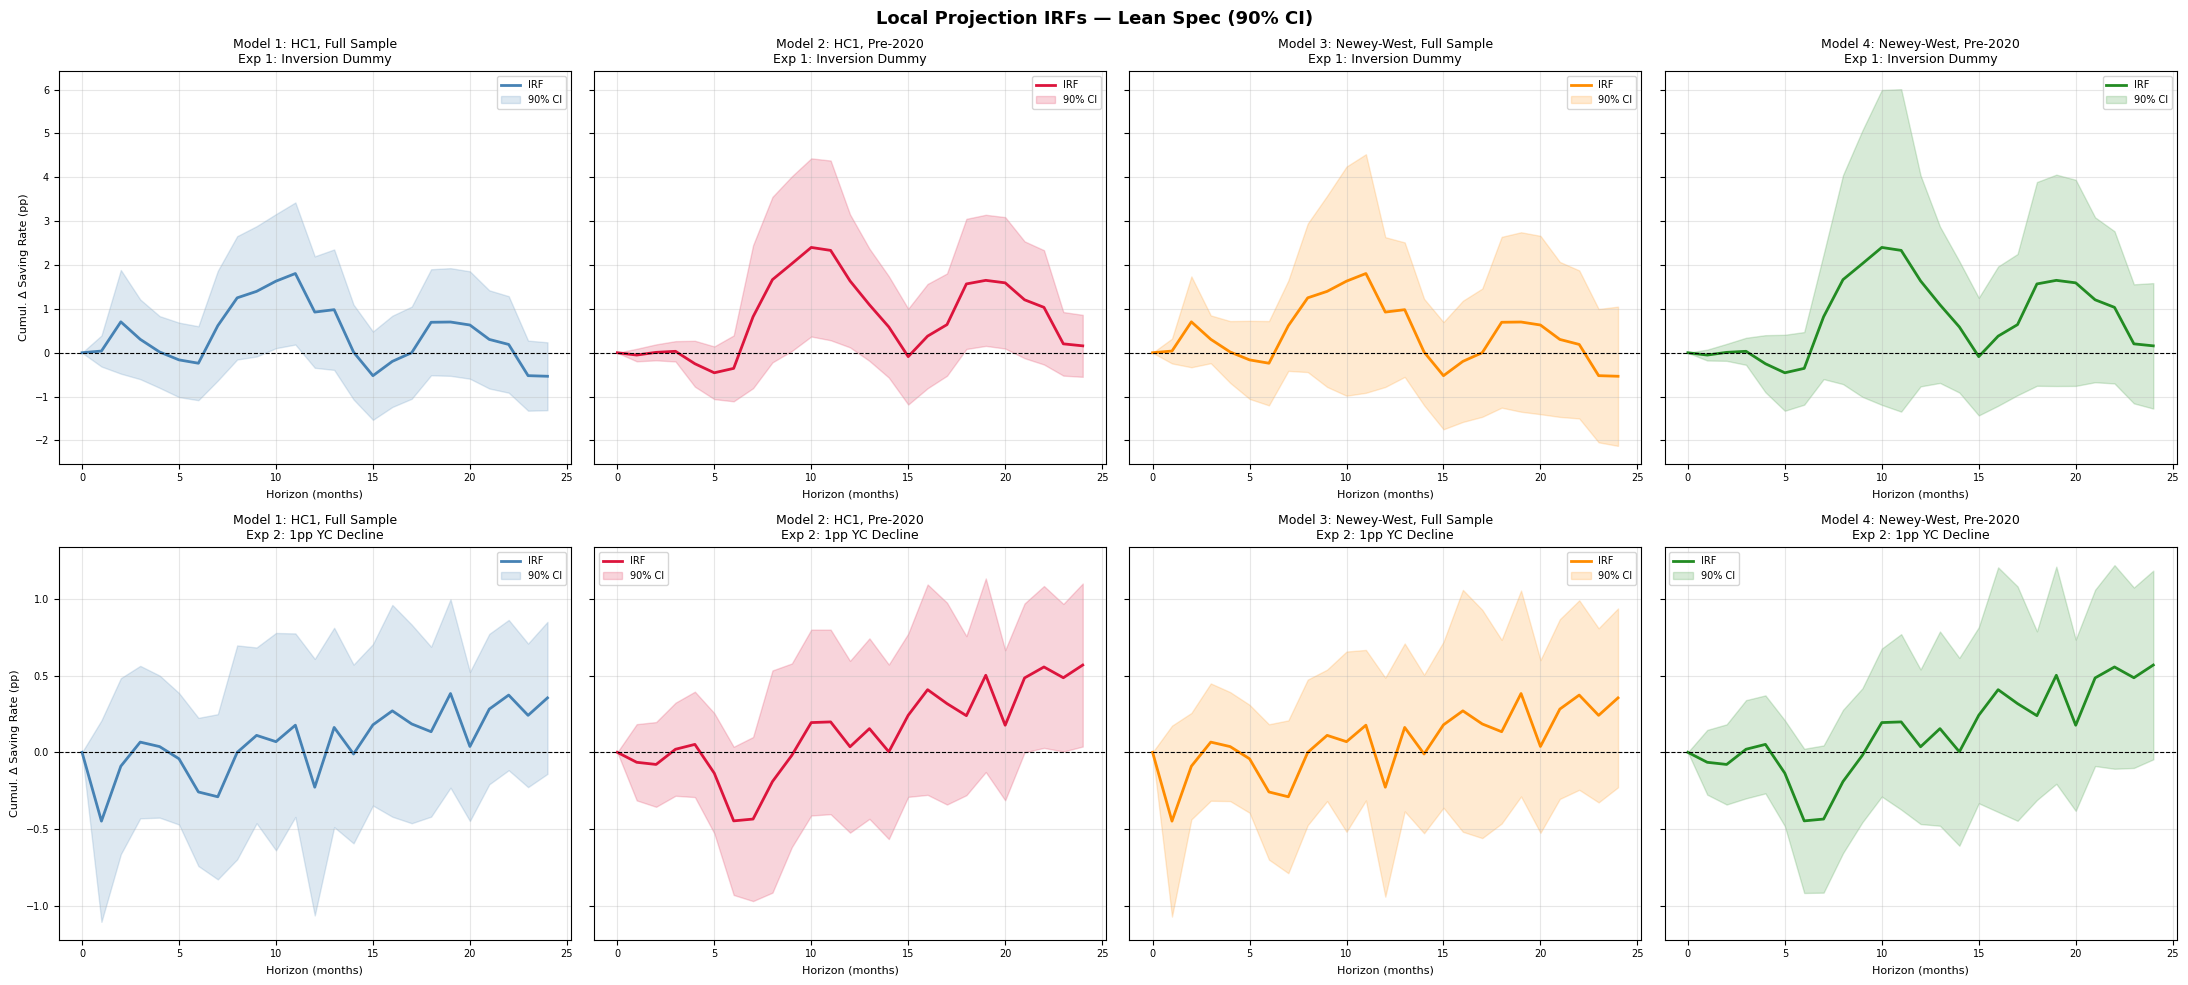


  Experiment 1: Yield Curve Inversion (Dummy) — Lean Spec
  Columns: coef = point estimate | ci_low / ci_high = 90% CI bounds
  [[coef]] = significant at 10% level (90% CI excludes zero)
           M1 coef  M1 ci_low  M1 ci_high    M2 coef  M2 ci_low  M2 ci_high M3 coef  M3 ci_low  M3 ci_high M4 coef  M4 ci_low  M4 ci_high
Horizon                                                                                                                                  
0             -0.0     -0.000      -0.000       -0.0     -0.000       0.000    -0.0     -0.000      -0.000    -0.0     -0.000       0.000
1            0.039     -0.315       0.393     -0.053     -0.196       0.090   0.039     -0.244       0.322  -0.053     -0.177       0.071
2            0.705     -0.477       1.887      0.009     -0.173       0.191   0.705     -0.331       1.740   0.009     -0.185       0.202
3            0.306     -0.602       1.215      0.033     -0.199       0.264   0.306     -0.239       0.851   0.033     -0.

In [18]:
##############################################################################
# 3.5.1 & 3.5.2  IRF Plots + Summary Tables — Lean spec
#
# Significance: ci_low > 0 OR ci_high < 0  →  90% CI excludes zero  →  *
##############################################################################

model_names_lean = [
    "Model 1: HC1, Full Sample",
    "Model 2: HC1, Pre-2020",
    "Model 3: Newey-West, Full Sample",
    "Model 4: Newey-West, Pre-2020",
]

irfs_exp1_lean = [irf1_m1_lean, irf1_m2_lean, irf1_m3_lean, irf1_m4_lean]
irfs_exp2_lean = [irf2_m1_lean, irf2_m2_lean, irf2_m3_lean, irf2_m4_lean]

colors = ["steelblue", "crimson", "darkorange", "forestgreen"]

# --- IRF plots: 2 rows x 4 cols ---
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey="row")

for col, (m_name, color) in enumerate(zip(model_names_lean, colors)):
    for row, (irfs, exp_label) in enumerate([
        (irfs_exp1_lean, "Exp 1: Inversion Dummy"),
        (irfs_exp2_lean, "Exp 2: 1pp YC Decline"),
    ]):
        ax  = axes[row, col]
        irf = irfs[col]

        ax.plot(irf["h"], irf["coef"], color=color, linewidth=2, label="IRF")
        ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"],
                        alpha=0.18, color=color, label="90% CI")
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_title(f"{m_name}\n{exp_label}", fontsize=9)
        ax.set_xlabel("Horizon (months)", fontsize=8)
        if col == 0:
            ax.set_ylabel("Cumul. Δ Saving Rate (pp)", fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

plt.suptitle("Local Projection IRFs — Lean Spec (90% CI)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# --- Summary tables with significance stars ---
def make_summary_table_lean(irfs, model_names, experiment_name):
    rows = []
    for h in range(len(irfs[0])):
        row = {"Horizon": h}
        for irf, name in zip(irfs, model_names):
            short   = name.replace("Model ", "M").split(":")[0].strip()
            coef    = round(irf.loc[h, "coef"],    3)
            ci_low  = round(irf.loc[h, "ci_low"],  3)
            ci_high = round(irf.loc[h, "ci_high"], 3)
            sig     = ci_low > 0 or ci_high < 0
            row[f"{short} coef"]    = f"[[{coef}]]" if sig else str(coef)
            row[f"{short} ci_low"]  = ci_low
            row[f"{short} ci_high"] = ci_high
        rows.append(row)

    df = pd.DataFrame(rows).set_index("Horizon")
    print(f"\n{'='*80}")
    print(f"  {experiment_name} — Lean Spec")
    print(f"  Columns: coef = point estimate | ci_low / ci_high = 90% CI bounds")
    print(f"  [[coef]] = significant at 10% level (90% CI excludes zero)")
    print(f"{'='*80}")
    print(df.to_string())
    return df


table_exp1_lean = make_summary_table_lean(
    irfs            = irfs_exp1_lean,
    model_names     = model_names_lean,
    experiment_name = "Experiment 1: Yield Curve Inversion (Dummy)"
)

table_exp2_lean = make_summary_table_lean(
    irfs            = irfs_exp2_lean,
    model_names     = model_names_lean,
    experiment_name = "Experiment 2: 1pp Decline in Yield Curve Spread"
)

In [19]:
##############################################################################
# 3.9  Joint Chi-Squared Test — Lean Spec, All Four Models
#
# Tests H0: beta^h = 0 for ALL h = 1, ..., 24 simultaneously.
#
# Method: chi2 = sum of z^2 where z = coef / SE
#         SE back-calculated from 90% CI: SE = (ci_high - ci_low) / (2 * 1.645)
# Under H0 this is distributed chi2(24).
#
# h=0 excluded — Cholesky ordering makes beta^0 = 0 by construction.
##############################################################################

from scipy import stats

H_test = 24

def pval_stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

def joint_chi2_test(irf, model_name, experiment_name, H_test=24):
    subset = irf[irf["h"].between(1, H_test)].copy()

    # Back out SE from 90% CI: SE = (ci_high - ci_low) / (2 * z_0.05)
    subset["se"]     = (subset["ci_high"] - subset["ci_low"]) / (2 * 1.6449)
    subset["z_stat"] = subset["coef"] / subset["se"]
    subset["pval_z"] = 2 * (1 - stats.norm.cdf(abs(subset["z_stat"])))

    chi2    = (subset["z_stat"] ** 2).sum()
    df      = len(subset)
    p_joint = stats.chi2.sf(chi2, df=df)

    print(f"\n  {model_name} | {experiment_name}")
    print(f"  {'─'*60}")
    print(f"  Horizons tested    : h = 1 to {H_test}  (n = {df})")
    print(f"  Chi2 statistic     : {chi2:.3f}")
    print(f"  Degrees of freedom : {df}")
    print(f"  Joint p-value      : {p_joint:.4f} {pval_stars(p_joint)}")

    top3 = subset.nsmallest(3, "pval_z")[["h", "coef", "se", "pval_z"]].copy()
    top3.columns = ["h", "coef", "se", "pval"]
    print(f"  Top 3 horizons     :")
    print(top3.to_string(index=False))

    return {"model": model_name, "experiment": experiment_name,
            "chi2": round(chi2, 3), "df": df,
            "p_joint": round(p_joint, 4), "stars": pval_stars(p_joint)}


# --- Run for all four models x two experiments ---
print("=" * 70)
print("  JOINT CHI-SQUARED TESTS — Lean Spec (h=1 to 24)")
print("=" * 70)

joint_results = []

for irf, m_name in [
    (irf1_m1_lean, "Model 1: HC1, Full"),
    (irf1_m2_lean, "Model 2: HC1, Pre-2020"),
    (irf1_m3_lean, "Model 3: HAC, Full"),
    (irf1_m4_lean, "Model 4: HAC, Pre-2020"),
]:
    joint_results.append(joint_chi2_test(irf, m_name, "Exp 1: Inversion Dummy"))

print()

for irf, m_name in [
    (irf2_m1_lean, "Model 1: HC1, Full"),
    (irf2_m2_lean, "Model 2: HC1, Pre-2020"),
    (irf2_m3_lean, "Model 3: HAC, Full"),
    (irf2_m4_lean, "Model 4: HAC, Pre-2020"),
]:
    joint_results.append(joint_chi2_test(irf, m_name, "Exp 2: 1pp YC Decline"))


# --- Summary pivot table ---
print(f"\n\n{'='*70}")
print("  JOINT TEST SUMMARY")
print(f"  H0: beta^h = 0 for all h = 1,...,24")
print(f"  * p<0.10  ** p<0.05  *** p<0.01")
print(f"{'='*70}")

summary_df = pd.DataFrame(joint_results)
summary_df["result"] = summary_df.apply(
    lambda r: f"chi2={r['chi2']:.2f}, p={r['p_joint']:.4f}{r['stars']}", axis=1
)
pivot = summary_df.pivot(index="model", columns="experiment", values="result")
print(pivot.to_string())

  JOINT CHI-SQUARED TESTS — Lean Spec (h=1 to 24)

  Model 1: HC1, Full | Exp 1: Inversion Dummy
  ────────────────────────────────────────────────────────────
  Horizons tested    : h = 1 to 24  (n = 24)
  Chi2 statistic     : 22.156
  Degrees of freedom : 24
  Joint p-value      : 0.5699 
  Top 3 horizons     :
 h     coef       se     pval
11 1.806604 0.984877 0.066603
10 1.632625 0.929287 0.078942
 9 1.399588 0.903285 0.121276

  Model 2: HC1, Pre-2020 | Exp 1: Inversion Dummy
  ────────────────────────────────────────────────────────────
  Horizons tested    : h = 1 to 24  (n = 24)
  Chi2 statistic     : 36.736
  Degrees of freedom : 24
  Joint p-value      : 0.0465 **
  Top 3 horizons     :
 h     coef       se     pval
10 2.401367 1.234939 0.051832
11 2.333855 1.245768 0.061009
19 1.650882 0.908868 0.069307

  Model 3: HAC, Full | Exp 1: Inversion Dummy
  ────────────────────────────────────────────────────────────
  Horizons tested    : h = 1 to 24  (n = 24)
  Chi2 statistic   

### 3.10 Robustness tests

#### 3.10.1 Lags check


--- Running LP models with p=1 lags ---

--- Running LP models with p=4 lags ---
All lag sensitivity models estimated successfully.


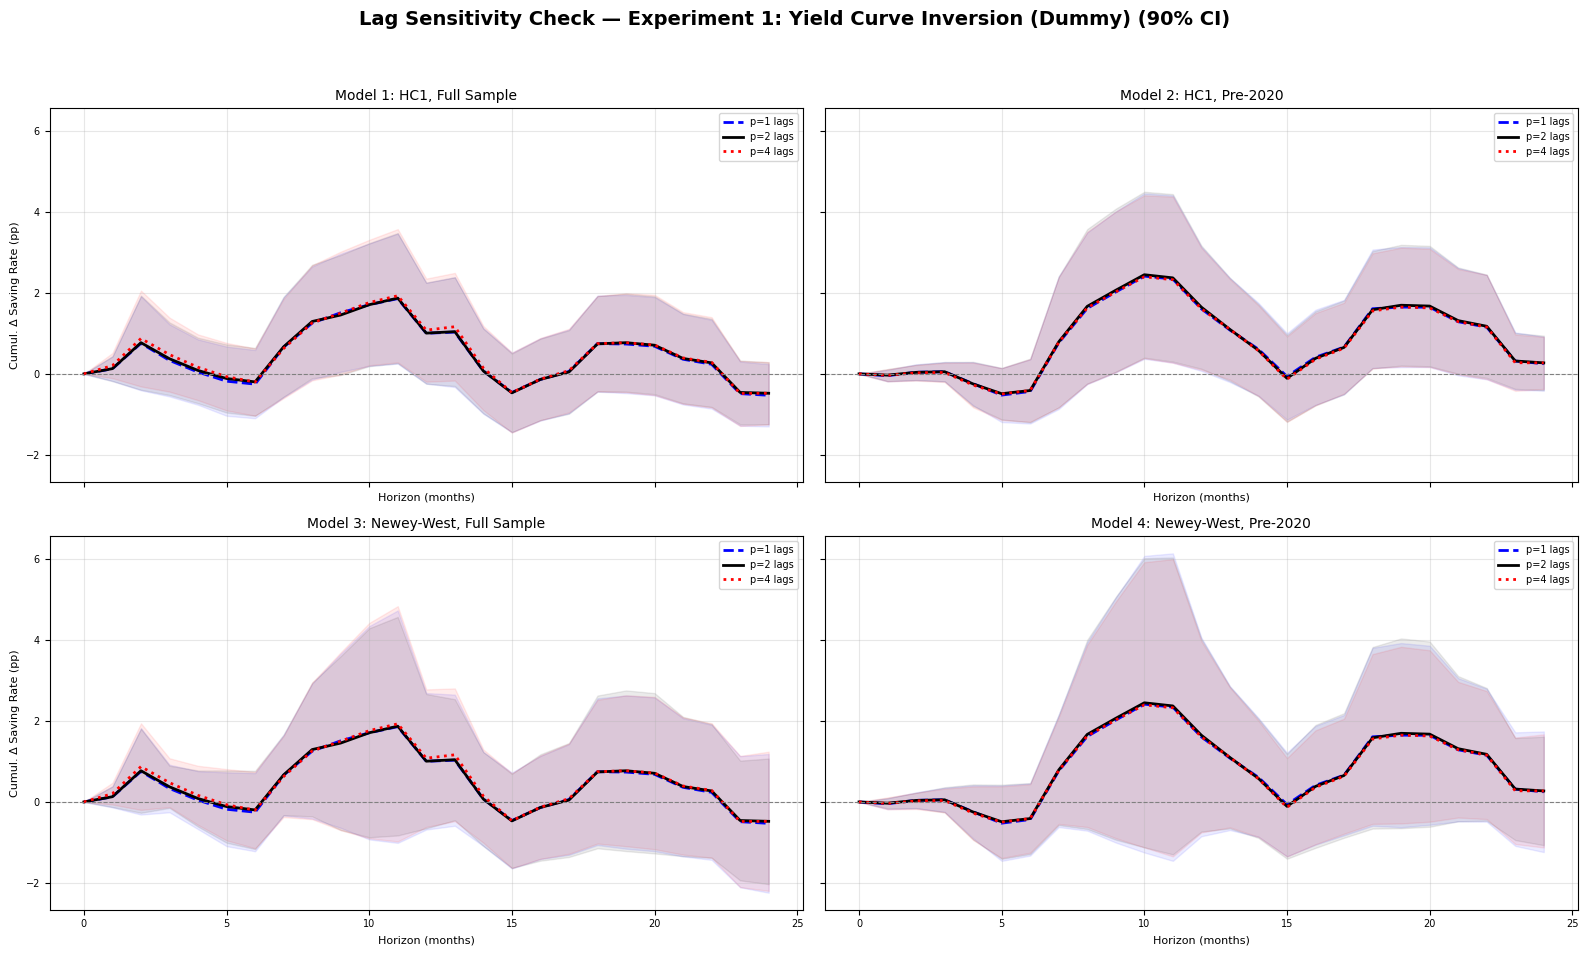

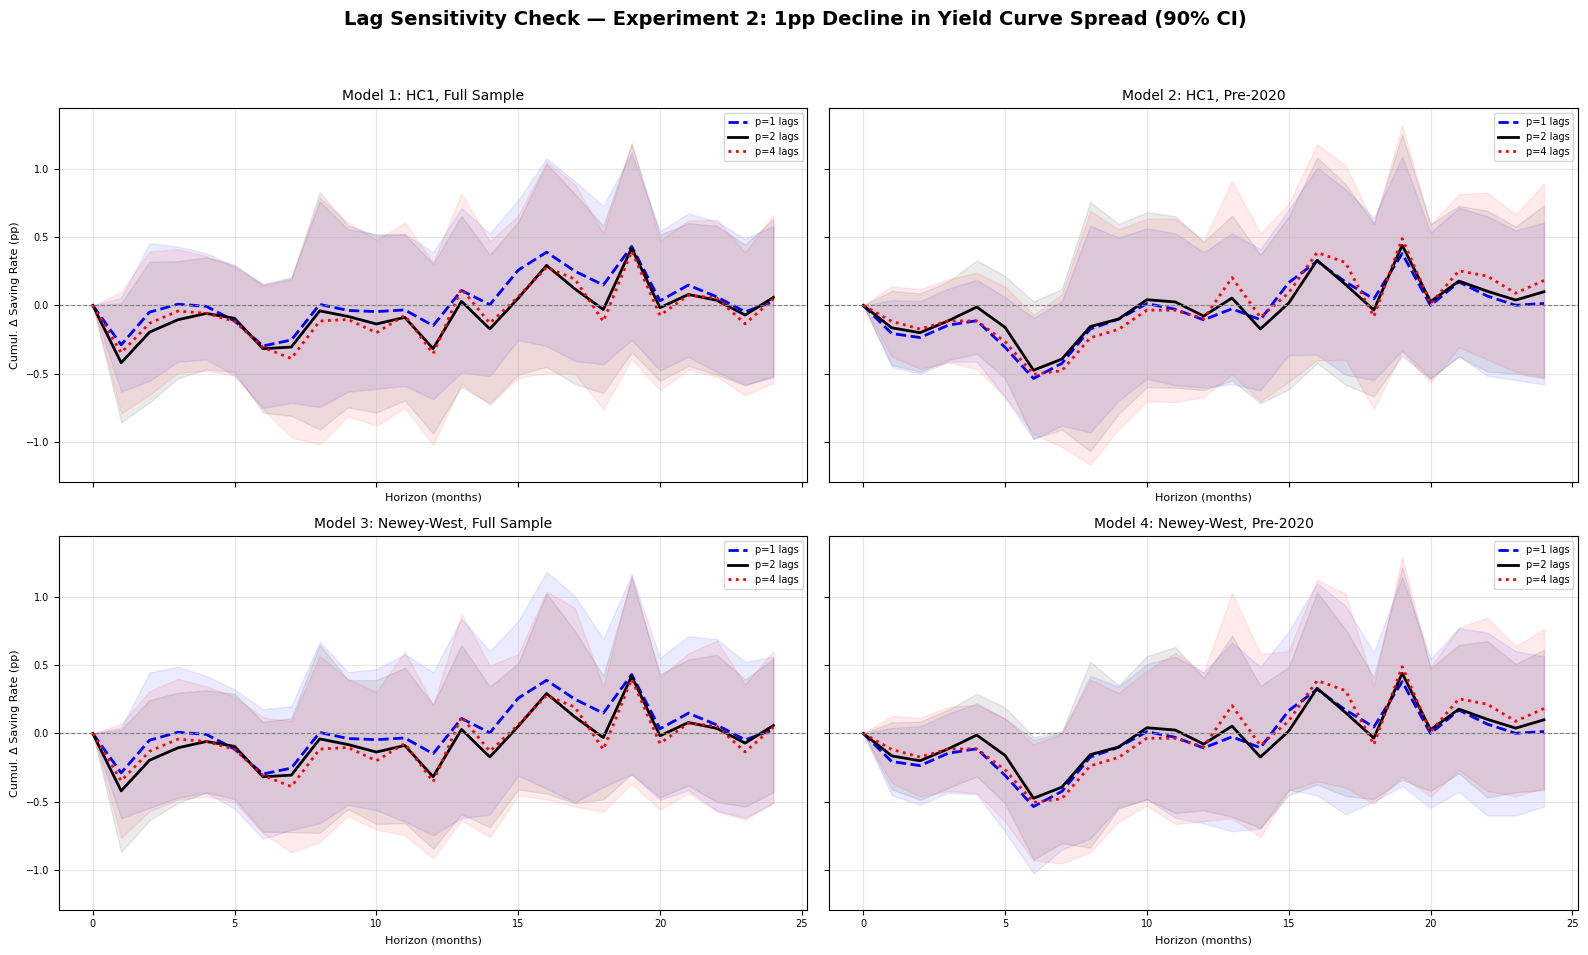

In [20]:
##############################################################################
# 3.10.1 Lags check
##############################################################################

def create_lp_dataset(df_final, p_lags, H=24):
    """
    Creates the local projection dataset for a given lag order p.
    """
    cols_to_keep = [
        "observation_date", "CPI", "PSAVERT", "T10Y3M",
        "d_DFF", "d_UNRATE", "DPI_Growth"
    ]
    df_lp_temp = df_final[cols_to_keep].copy()

    # --- Experiment 1: Inversion dummy ---
    df_lp_temp["D_inversion"] = (df_lp_temp["T10Y3M"] < 0).astype(int)

    # --- Dummies: COVID and Recession ---
    df_lp_temp["D_covid"] = ((df_lp_temp["observation_date"] >= "2020-03-01") &
                         (df_lp_temp["observation_date"] <= "2021-06-01")).astype(int)

    # Merge recession data (assuming 'recession' is already loaded)
    df_lp_temp = df_lp_temp.merge(recession[['observation_date', 'USREC']], on="observation_date", how="left")
    df_lp_temp.rename(columns={"USREC": "D_recession"}, inplace=True)
    df_lp_temp["D_recession"] = df_lp_temp["D_recession"].fillna(0).astype(int)

    # --- Lag matrix: p lags of ALL variables ---
    vars_to_lag = ["CPI", "PSAVERT", "T10Y3M", "d_DFF", "d_UNRATE", "DPI_Growth"]
    for lag in range(1, p_lags + 1):
        for var in vars_to_lag:
            df_lp_temp[f"{var}_L{lag}"] = df_lp_temp[var].shift(lag)

    # --- Outcome variables: cumulative change in PSAVERT at each horizon h ---
    df_lp_temp["PSAVERT_Lminus1"] = df_lp_temp["PSAVERT"].shift(1)
    for h in range(0, H + 1):
        df_lp_temp[f"y_h{h}"] = df_lp_temp["PSAVERT"].shift(-h) - df_lp_temp["PSAVERT_Lminus1"]

    return df_lp_temp.dropna().reset_index(drop=True)


# --- Define a wrapper function for run_lp_model with different lag sets ---
def run_lp_models_for_lags(p_lags, H=24):
    print(f"\n--- Running LP models with p={p_lags} lags ---")
    df_lp_current = create_lp_dataset(df_final, p_lags, H=H)

    # Create the pre-2020 dataset for the current lag setup
    df_lp_pre2020_current = df_lp_current.query("observation_date < '2020-01-01'").copy()
    if "D_covid" in df_lp_pre2020_current.columns:
        df_lp_pre2020_current = df_lp_pre2020_current.drop(columns=["D_covid"])

    # --- Helper function for this specific lag setting ---
    def run_lp_model_with_current_lags(data, se_type):
        # Redefine lag_cols for the current p_lags
        current_lag_cols = []
        vars_to_lag = ["CPI", "PSAVERT", "T10Y3M", "d_DFF", "d_UNRATE", "DPI_Growth"]
        for l in range(1, p_lags + 1):
            for var in vars_to_lag:
                current_lag_cols.append(f"{var}_L{l}")

        results_exp1_model = []
        results_exp2_model = []
        avail_outlier_controls = [c for c in outlier_controls if c in data.columns]

        for h in range(0, H + 1):
            y = data[f"y_h{h}"]

            if se_type == "HC1":
                fit_kwargs = {"cov_type": "HC1"}
            else:
                fit_kwargs = {"cov_type": "HAC", "cov_kwds": {"maxlags": min(h + 1, 12)}}

            # Experiment 1: Inversion dummy
            cols1 = ["D_inversion"] + contemp_controls + policy_controls + avail_outlier_controls + current_lag_cols
            cols1 = [c for c in cols1 if c in data.columns]
            X1 = sm.add_constant(data[cols1])
            model1 = sm.OLS(y, X1).fit(**fit_kwargs)
            coef1 = model1.params["D_inversion"]
            pval1 = model1.pvalues["D_inversion"]
            ci1 = model1.conf_int(alpha=0.10).loc["D_inversion"]
            results_exp1_model.append({"h": h, "coef": coef1, "ci_low": ci1[0], "ci_high": ci1[1], "pval": pval1, "model": model1})

            # Experiment 2: 1pp decline in YC Spread
            cols2 = ["T10Y3M"] + contemp_controls + policy_controls + avail_outlier_controls + current_lag_cols
            cols2 = [c for c in cols2 if c in data.columns]
            X2 = sm.add_constant(data[cols2])
            model2 = sm.OLS(y, X2).fit(**fit_kwargs)
            coef2 = model2.params["T10Y3M"]
            pval2 = model2.pvalues["T10Y3M"]
            ci2 = model2.conf_int(alpha=0.10).loc["T10Y3M"]
            shock_size = -1
            results_exp2_model.append({
                "h": h,
                "coef": coef2 * shock_size,
                "ci_low": min(ci2[0] * shock_size, ci2[1] * shock_size),
                "ci_high": max(ci2[0] * shock_size, ci2[1] * shock_size),
                "pval": pval2, "model": model2
            })
        return pd.DataFrame(results_exp1_model), pd.DataFrame(results_exp2_model)

    irf1_m1, irf2_m1 = run_lp_model_with_current_lags(df_lp_current, "HC1")
    irf1_m2, irf2_m2 = run_lp_model_with_current_lags(df_lp_pre2020_current, "HC1")
    irf1_m3, irf2_m3 = run_lp_model_with_current_lags(df_lp_current, "HAC")
    irf1_m4, irf2_m4 = run_lp_model_with_current_lags(df_lp_pre2020_current, "HAC")
    return irf1_m1, irf2_m1, irf1_m2, irf2_m2, irf1_m3, irf2_m3, irf1_m4, irf2_m4


# --- Run for different lag orders ---
# Using p_bic = 2 from previous analysis as the baseline
p_lags_to_test = [1, 4] # Test p=1 and p=4

all_irfs_exp1_lags = {}
all_irfs_exp2_lags = {}

# Include the baseline p_bic = 2 results for comparison
all_irfs_exp1_lags[p_bic] = [irf1_m1, irf1_m2, irf1_m3, irf1_m4]
all_irfs_exp2_lags[p_bic] = [irf2_m1, irf2_m2, irf2_m3, irf2_m4]

for p_val in p_lags_to_test:
    irf1_m1_p, irf2_m1_p, irf1_m2_p, irf2_m2_p, irf1_m3_p, irf2_m3_p, irf1_m4_p, irf2_m4_p = run_lp_models_for_lags(p_val)
    all_irfs_exp1_lags[p_val] = [irf1_m1_p, irf1_m2_p, irf1_m3_p, irf1_m4_p]
    all_irfs_exp2_lags[p_val] = [irf2_m1_p, irf2_m2_p, irf2_m3_p, irf2_m4_p]

print("All lag sensitivity models estimated successfully.")


# --- Plotting function for lag sensitivity ---
def plot_lag_sensitivity(all_irfs, experiment_label):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True, sharex=True)
    axes_flat = axes.flatten()

    model_index_map = {"HC1, Full Sample": 0, "HC1, Pre-2020": 1, "Newey-West, Full Sample": 2, "Newey-West, Pre-2020": 3}
    model_titles = list(model_index_map.keys())
    plot_colors = ["steelblue", "crimson", "forestgreen", "darkorange"]
    lag_colors = {p_bic: "black", 1: "blue", 4: "red"}
    lag_linestyles = {p_bic: "-", 1: "--", 4: ":"}

    for i, title in enumerate(model_titles):
        ax = axes_flat[i]
        for p_val in sorted(all_irfs.keys()):
            irf = all_irfs[p_val][i]
            ax.plot(irf["h"], irf["coef"], color=lag_colors[p_val], linestyle=lag_linestyles[p_val], linewidth=2, label=f"p={p_val} lags")
            ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"],
                            alpha=0.08, color=lag_colors[p_val]) # Lighter fill for clarity
        ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
        ax.set_title(f"Model {i+1}: {title}", fontsize=10)
        ax.set_xlabel("Horizon (months)", fontsize=8)
        if i % 2 == 0: # Left column
            ax.set_ylabel("Cumul. \u0394 Saving Rate (pp)", fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7, loc="upper right")

    plt.suptitle(f"Lag Sensitivity Check — {experiment_label} (90% CI)",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# --- Plot results ---
plot_lag_sensitivity(all_irfs_exp1_lags, "Experiment 1: Yield Curve Inversion (Dummy)")
plot_lag_sensitivity(all_irfs_exp2_lags, "Experiment 2: 1pp Decline in Yield Curve Spread")


#### 3.10.2 Placebo

Reshuffles D_inversion 500 times and plots the 5th–95th percentile band of the placebo distribution. If your true IRF sits above the grey band in the h=8–12 range, the result is not spurious.

  Placebo run 100/500...
  Placebo run 200/500...
  Placebo run 300/500...
  Placebo run 400/500...
  Placebo run 500/500...
Placebo runs complete.


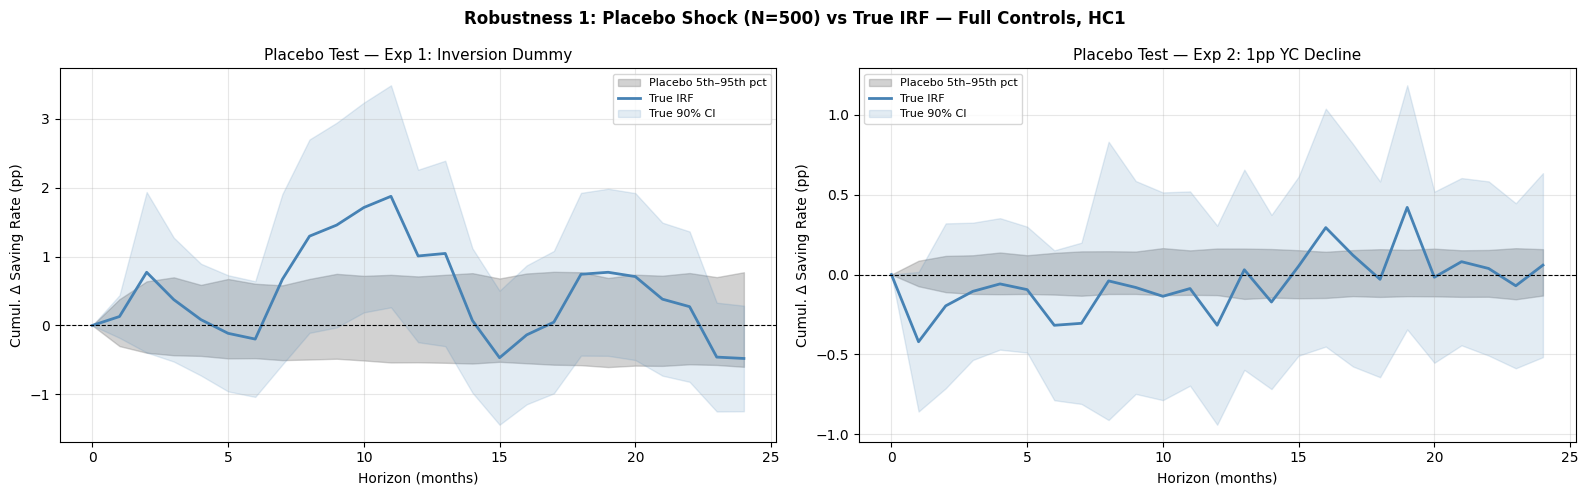

In [21]:
##############################################################################
# ROBUSTNESS 1 — Placebo Shock
#
# Replace D_inversion with a randomly shuffled version.
# If the shuffled IRF looks similar to the real one, the result is spurious.
# We run 500 placebo IRFs and overlay the percentile band vs the true IRF.
#
# Uses full-control spec, Model 1 (HC1, Full Sample) as baseline.
##############################################################################

import statsmodels.api as sm
import numpy as np

N_PLACEBO = 500
np.random.seed(42)

avail_outlier = [c for c in outlier_controls if c in df_lp.columns]

placebo_coefs_exp1 = np.zeros((N_PLACEBO, H + 1))
placebo_coefs_exp2 = np.zeros((N_PLACEBO, H + 1))

for b in range(N_PLACEBO):
    df_placebo = df_lp.copy()
    df_placebo["D_inversion_pl"] = np.random.permutation(df_lp["D_inversion"].values)
    df_placebo["T10Y3M_pl"]      = np.random.permutation(df_lp["T10Y3M"].values)

    for h in range(0, H + 1):
        y = df_placebo[f"y_h{h}"]

        # Exp 1: shuffled inversion dummy
        cols1 = [c for c in ["D_inversion_pl"] + contemp_controls + policy_controls
                 + avail_outlier + lag_cols if c in df_placebo.columns]
        m1 = sm.OLS(y, sm.add_constant(df_placebo[cols1])).fit(cov_type="HC1")
        placebo_coefs_exp1[b, h] = m1.params["D_inversion_pl"]

        # Exp 2: shuffled T10Y3M
        cols2 = [c for c in ["T10Y3M_pl"] + contemp_controls + policy_controls
                 + avail_outlier + lag_cols if c in df_placebo.columns]
        m2 = sm.OLS(y, sm.add_constant(df_placebo[cols2])).fit(cov_type="HC1")
        placebo_coefs_exp2[b, h] = m2.params["T10Y3M_pl"] * -1

    if (b + 1) % 100 == 0:
        print(f"  Placebo run {b+1}/{N_PLACEBO}...")

print("Placebo runs complete.")

# --- Percentile bands ---
horizons = np.arange(H + 1)
p5_exp1  = np.percentile(placebo_coefs_exp1,  5, axis=0)
p95_exp1 = np.percentile(placebo_coefs_exp1, 95, axis=0)
p5_exp2  = np.percentile(placebo_coefs_exp2,  5, axis=0)
p95_exp2 = np.percentile(placebo_coefs_exp2, 95, axis=0)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, irf, p5, p95, title in zip(
    axes,
    [irf1_m1, irf2_m1],
    [p5_exp1,  p5_exp2],
    [p95_exp1, p95_exp2],
    ["Exp 1: Inversion Dummy", "Exp 2: 1pp YC Decline"]
):
    ax.fill_between(horizons, p5, p95,
                    color="grey", alpha=0.35, label="Placebo 5th–95th pct")
    ax.plot(irf["h"], irf["coef"],
            color="steelblue", linewidth=2, label="True IRF")
    ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"],
                    alpha=0.15, color="steelblue", label="True 90% CI")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Placebo Test — {title}", fontsize=11)
    ax.set_xlabel("Horizon (months)")
    ax.set_ylabel("Cumul. Δ Saving Rate (pp)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Robustness 1: Placebo Shock (N=500) vs True IRF — Full Controls, HC1",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

#### 3.10.3 Inflation as the outcome

Runs the exact same LP but with cumulative Δ Inflation as the LHS. You want to see a flat, insignificant IRF here — that would tell the reader the yield curve predicts saving behavior, not just general macro conditions, which directly supports the precautionary saving channel.

/tmp/ipykernel_12483/7930546.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_lp_inf["CPI_Lminus1"] = df_lp_inf["CPI"].shift(1).fillna(method="bfill")


Inflation outcome dataset: 475 obs (full), 453 (pre-2020)
Running inflation LP (HC1, Full)...
Running inflation LP (HC1, Pre-2020)...
Done.


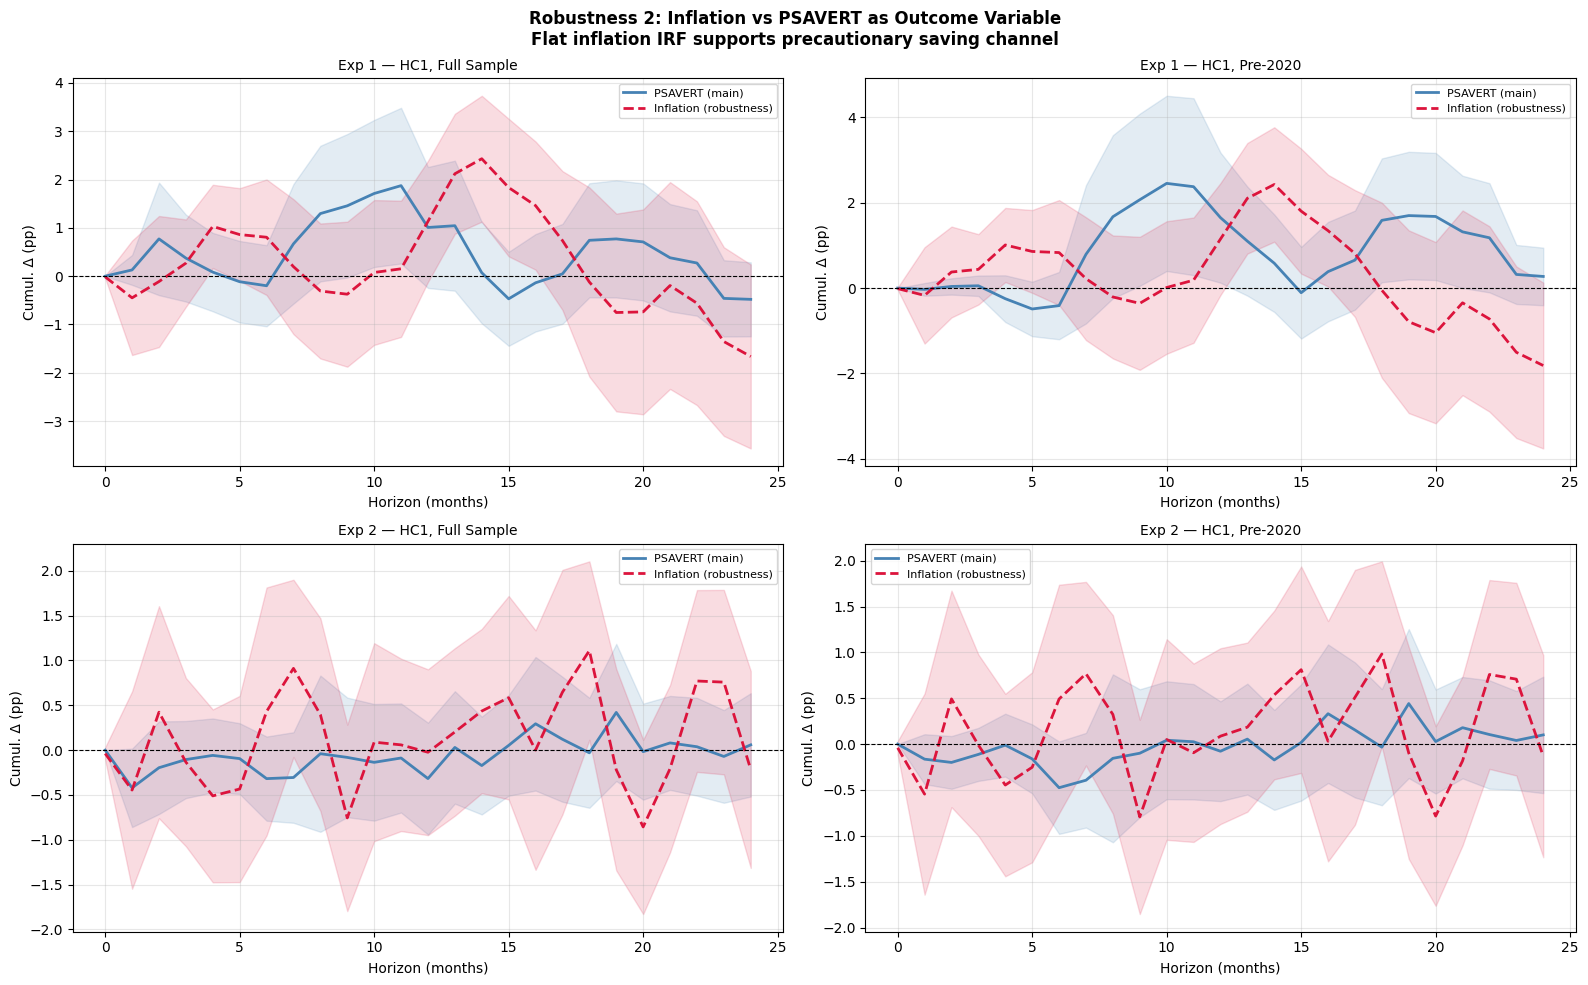

In [22]:
##############################################################################
# ROBUSTNESS 2 — Inflation as Outcome Variable
#
# Re-runs the LP with CPI Inflation as the dependent variable instead of
# Personal Saving Rate.
#
# Interpretation: if the yield curve predicts saving but NOT inflation,
# this supports the precautionary saving channel over the monetary/price channel.
# We expect a flat/noisy IRF here — that would strengthen the main result.
#
# Outcome: Inflation_{t+h} - Inflation_{t-1}  (cumulative change)
# Uses full-control spec, Models 1 & 2 (HC1 Full + HC1 Pre-2020)
##############################################################################

import statsmodels.api as sm

avail_outlier = [c for c in outlier_controls if c in df_lp.columns]

# --- Build inflation outcome variables ---
# We need Inflation_{t+h} - Inflation_{t-1} analogous to the PSAVERT outcome
df_lp_inf = df_lp.copy()
df_lp_inf["CPI_Lminus1"] = df_lp_inf["CPI"].shift(1).fillna(method="bfill")

# Recalculate outcomes using Inflation instead of PSAVERT
# (df_lp already has lags computed; we just swap the LHS)
for h in range(0, H + 1):
    df_lp_inf[f"y_inf_h{h}"] = (df_lp_inf["CPI"].shift(-h)
                                 - df_lp_inf["CPI_Lminus1"])

df_lp_inf = df_lp_inf.dropna().reset_index(drop=True)
df_lp_inf_pre2020 = df_lp_inf[df_lp_inf["observation_date"] < "2020-01-01"].copy().reset_index(drop=True)

print(f"Inflation outcome dataset: {len(df_lp_inf)} obs (full), {len(df_lp_inf_pre2020)} (pre-2020)")

# --- Run LP with inflation outcome ---
def run_lp_inf(data, se_type, H=H):
    res1, res2 = [], []
    avail_ol = [c for c in outlier_controls if c in data.columns]

    for h in range(0, H + 1):
        y = data[f"y_inf_h{h}"]

        fit_kwargs = ({"cov_type": "HC1"} if se_type == "HC1"
                      else {"cov_type": "HAC", "cov_kwds": {"maxlags": h + 1}})

        cols1 = [c for c in ["D_inversion"] + contemp_controls + policy_controls
                 + avail_ol + lag_cols if c in data.columns]
        m1  = sm.OLS(y, sm.add_constant(data[cols1])).fit(**fit_kwargs)
        ci1 = m1.conf_int(alpha=0.10).loc["D_inversion"]
        res1.append({"h": h, "coef": m1.params["D_inversion"],
                     "ci_low": ci1[0], "ci_high": ci1[1]})

        cols2 = [c for c in ["T10Y3M"] + contemp_controls + policy_controls
                 + avail_ol + lag_cols if c in data.columns]
        m2    = sm.OLS(y, sm.add_constant(data[cols2])).fit(**fit_kwargs)
        coef2 = m2.params["T10Y3M"]
        ci2   = m2.conf_int(alpha=0.10).loc["T10Y3M"]
        shock = -1
        res2.append({"h": h, "coef": coef2 * shock,
                     "ci_low":  min(ci2[0] * shock, ci2[1] * shock),
                     "ci_high": max(ci2[0] * shock, ci2[1] * shock)})

    return pd.DataFrame(res1), pd.DataFrame(res2)


print("Running inflation LP (HC1, Full)...")
irf1_inf_m1, irf2_inf_m1 = run_lp_inf(df_lp_inf,         "HC1")
print("Running inflation LP (HC1, Pre-2020)...")
irf1_inf_m2, irf2_inf_m2 = run_lp_inf(df_lp_inf_pre2020, "HC1")
print("Done.")

# --- Plot: Inflation IRF vs PSAVERT IRF side by side ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

pairs = [
    (irf1_m1,     irf1_inf_m1, "Exp 1 — HC1, Full Sample"),
    (irf1_m2,     irf1_inf_m2, "Exp 1 — HC1, Pre-2020"),
    (irf2_m1,     irf2_inf_m1, "Exp 2 — HC1, Full Sample"),
    (irf2_m2,     irf2_inf_m2, "Exp 2 — HC1, Pre-2020"),
]

for ax, (irf_psr, irf_inf, title) in zip(axes.flat, pairs):
    ax.plot(irf_psr["h"], irf_psr["coef"],
            color="steelblue", linewidth=2, label="PSAVERT (main)")
    ax.fill_between(irf_psr["h"], irf_psr["ci_low"], irf_psr["ci_high"],
                    alpha=0.15, color="steelblue")
    ax.plot(irf_inf["h"], irf_inf["coef"],
            color="crimson", linewidth=2, linestyle="--", label="Inflation (robustness)")
    ax.fill_between(irf_inf["h"], irf_inf["ci_low"], irf_inf["ci_high"],
                    alpha=0.15, color="crimson")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Horizon (months)")
    ax.set_ylabel("Cumul. Δ (pp)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Robustness 2: Inflation vs PSAVERT as Outcome Variable\n"
             "Flat inflation IRF supports precautionary saving channel",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

#### 3.10.3 Rolling window / Structural breaks

Rolling window + GFC split: Part A tracks β^10 across all 15-year rolling windows with a vertical line at September 2008. Part B compares pre-GFC vs post-GFC IRFs directly. If the pre-GFC IRF is stronger, that's worth discussing — the GFC may have changed how households respond to financial signals.

In [28]:
##############################################################################
# ROBUSTNESS 3D — Two-Regime Visualization & Joint Chi2 Tests
# Includes the prerequisite LP estimation steps to define irf_X variables.
##############################################################################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings("ignore")

# ── 0. Helper Function to Estimate LPs for a Specific Time Period ────────────

def estimate_regime_lp(df, start_year, end_year, use_dummy=False):
    """
    Filters the panel to a specific time period and runs the pooled LP.
    Returns a DataFrame with columns: h, coef, se, ci_low, ci_high
    """
    df_sub = df[(df["year"] >= start_year) & (df["year"] <= end_year)].copy()

    # We use a pooled approach for this robustness check (averaging across quintiles)
    # as the goal here is to show aggregate time-series structural breaks.

    # Define max horizon. If the regime is very short (like 2009-2019),
    # a horizon of 5 years is the maximum we can reliably estimate.
    MAX_H = 5
    N_LAGS = MAX_H
    ALPHA = 0.10

    lag_cols = [f"dPSR_L{lag}" for lag in range(1, N_LAGS + 1)]
    x_var = "Inversion" if use_dummy else "Spread"

    results = []
    for h in range(0, MAX_H + 1):
        temp = df_sub.copy()
        temp[f"cum_dPSR_h{h}"] = temp.groupby("quintile")["PSR"].shift(-h).values - temp["PSR"].values

        # Run OLS with Robust SEs (borrowing the function from previous steps)
        cols_needed = [f"cum_dPSR_h{h}", x_var] + lag_cols
        sub = temp[cols_needed].dropna()

        if len(sub) < 20:
            results.append({"h": h, "coef": np.nan, "ci_low": np.nan, "ci_high": np.nan})
            continue

        X = pd.concat([pd.Series(1.0, index=sub.index, name="const"), sub[x_var], sub[lag_cols]], axis=1).astype(float)
        y = sub[f"cum_dPSR_h{h}"].astype(float)

        Xmat = X.values
        yvec = y.values
        try:
            XtX_inv = np.linalg.pinv(Xmat.T @ Xmat)
            beta = XtX_inv @ (Xmat.T @ yvec)
            resid = yvec - Xmat @ beta

            n, k = Xmat.shape
            meat = (Xmat * resid[:, None]).T @ (Xmat * resid[:, None])
            V_cov = (n / (n - k)) * XtX_inv @ meat @ XtX_inv
            se_cov = np.sqrt(np.diag(V_cov))

            coef_val = beta[1]
            se_val = se_cov[1]
            df_t = n - k
            t_crit = scipy_stats.t.ppf(1 - ALPHA / 2, df=df_t)

            results.append({
                "h": h,
                "coef": coef_val,
                "se": se_val,
                "ci_low": coef_val - t_crit * se_val,
                "ci_high": coef_val + t_crit * se_val
            })
        except np.linalg.LinAlgError:
            results.append({"h": h, "coef": np.nan, "ci_low": np.nan, "ci_high": np.nan})

    return pd.DataFrame(results)

# ── 0.5 Generate the missing IRF DataFrames ──────────────────────────────────

print("Estimating Local Projections for each regime...")

# Experiment 1: Inversion Dummy (1 if Spread < 0, 0 otherwise)
# Note: Using an annual inversion dummy might fail if there are no inversions in that window.
# We will use it here since the user's prompt requests it, but Exp 2 is more reliable.
if "Inversion" not in df_lp.columns:
    df_lp["Inversion"] = (df_lp["Spread"] < 0).astype(int)

irf1_A = estimate_regime_lp(df_lp, 1982, 2007, use_dummy=True)  # Pre-GFC
irf1_C = estimate_regime_lp(df_lp, 2009, 2019, use_dummy=True)  # Post-GFC
irf1_B = estimate_regime_lp(df_lp, 1982, 2019, use_dummy=True)  # Main Sample

# Experiment 2: 1pp Decline in Yield Curve Spread
# To interpret a 1pp *decline* as a positive shock, we multiply the spread by -1
df_lp["Neg_Spread"] = -1 * df_lp["Spread"]

# Temporarily redefine estimate_regime_lp to use "Neg_Spread" for Exp 2
def estimate_regime_lp_exp2(df, start_year, end_year):
    df_temp = df.copy()
    df_temp["Spread"] = df_temp["Neg_Spread"] # Swap in the negative spread
    return estimate_regime_lp(df_temp, start_year, end_year, use_dummy=False)

irf2_A = estimate_regime_lp_exp2(df_lp, 1982, 2007)
irf2_C = estimate_regime_lp_exp2(df_lp, 2009, 2019)
irf2_B = estimate_regime_lp_exp2(df_lp, 1982, 2019)


# ── 1. Two-Regime IRF Plot ───────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

regime_specs = [
    (irf1_A, irf1_C, "Exp 1: Inversion Dummy"),
    (irf2_A, irf2_C, "Exp 2: 1pp YC Decline"),
]

for col, (irf_pre, irf_post, exp_title) in enumerate(regime_specs):

    # We need to map the code to the variables to plot them correctly
    plot_data = [
        (irf_pre,  "Pre-GFC Regime (1982–2007)",       "steelblue", "Near-zero: credit availability neutralised\nprecautionary motive"),
        (irf_post, "Post-GFC Regime (2009–2019)",       "crimson",   "Large effect: credit constraints +\nheightened recession awareness")
    ]

    for row, (irf, regime_label, color, note) in enumerate(plot_data):
        ax = axes[row, col]

        # Only plot if we have valid coefficients (some short regimes might fail to estimate)
        if irf["coef"].isna().all():
            ax.text(0.5, 0.5, "Insufficient Data/Variation\nto Estimate Regime",
                    ha='center', va='center', transform=ax.transAxes, color='gray')
            ax.set_title(f"{regime_label}\n{exp_title}", fontsize=10)
            continue

        ax.plot(irf["h"], irf["coef"], color=color, linewidth=2.5, label="IRF")
        ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"], alpha=0.18, color=color, label="90% CI")
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

        # Shade the hump window (adjusted for annual data: h=1 to 3 years)
        ax.axvspan(1, 3, alpha=0.06, color="gold", label="Hump window (h=1–3 yrs)")

        ax.set_title(f"{regime_label}\n{exp_title}", fontsize=10)
        ax.set_xlabel("Horizon (years)", fontsize=9)
        ax.set_ylabel("Cumul. Δ Saving Rate (pp)", fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

# Annotate peak coefficient
        valid_irf = irf.dropna(subset=['coef'])
        if not valid_irf.empty:
            peak_idx = valid_irf["coef"].idxmax()
            peak_h   = valid_irf.loc[peak_idx, "h"]
            peak_val = valid_irf.loc[peak_idx, "coef"]
            ax.annotate(f"Peak: {peak_val:.2f}pp\n(h={peak_h})",
                        xy=(peak_h, peak_val),
                        xytext=(peak_h + 0.5, peak_val + 0.5),
                        arrowprops=dict(arrowstyle="->", color=color),
                        fontsize=8, color=color)

plt.suptitle("Two-Regime Finding: Yield Curve Flattening/Inversion → Personal Saving Rate\n"
             "Structural break at GFC — channel activated post-2008",
             fontsize=14, fontweight="bold")

# FIX: Replaced tight_layout with explicit spacing to avoid the RendererAgg int/float crash
plt.subplots_adjust(top=0.85, bottom=0.1, left=0.1, right=0.9, hspace=0.4, wspace=0.25)
plt.show()

# ── 2. Joint Chi2 Test by Regime ─────────────────────────────────────────────

def joint_chi2_regime(irf, label, H_test=5):
    # Only test rows where we successfully estimated a coefficient
    subset = irf[(irf["h"].between(1, H_test)) & (irf["coef"].notna())].copy()

    if subset.empty:
        print(f"\n  {label}\n  {'─'*58}\n  Could not calculate Chi2 (insufficient data)")
        return None

    # Recalculate z-stat from standard error if available
    if "se" in subset.columns:
        subset["z_stat"] = subset["coef"] / subset["se"]
    else:
        subset["se"]     = (subset["ci_high"] - subset["ci_low"]) / (2 * 1.6449)
        subset["z_stat"] = subset["coef"] / subset["se"]

    subset["pval_z"] = 2 * (1 - scipy_stats.norm.cdf(abs(subset["z_stat"])))

    chi2    = (subset["z_stat"] ** 2).sum()
    df      = len(subset)
    p_joint = scipy_stats.chi2.sf(chi2, df=df)
    stars   = ("***" if p_joint < 0.01 else "**" if p_joint < 0.05
               else "*" if p_joint < 0.10 else "")

    print(f"\n  {label}")
    print(f"  {'─'*58}")
    print(f"  Chi2 = {chi2:.3f}  |  df = {df}  |  "
          f"p = {p_joint:.4f} {stars}")

    top_n = min(3, len(subset))
    top = subset.nsmallest(top_n, "pval_z")[["h", "coef", "pval_z"]]
    top.columns = ["h", "coef", "pval"]
    print(f"  Top {top_n} horizons: \n{top.to_string(index=False)}")

    return {"label": label, "chi2": round(chi2,3), "df": df, "p": round(p_joint,4), "stars": stars}


print("\n" + "=" * 65)
print("  JOINT CHI2 TESTS BY REGIME — Exp 1: Inversion Dummy")
print("=" * 65)
jt_pregfc_e1  = joint_chi2_regime(irf1_A, "Pre-GFC  (1982–2007)")
jt_postgfc_e1 = joint_chi2_regime(irf1_C, "Post-GFC (2009–2019)")

print("\n" + "=" * 65)
print("  JOINT CHI2 TESTS BY REGIME — Exp 2: 1pp YC Decline")
print("=" * 65)
jt_pregfc_e2  = joint_chi2_regime(irf2_A, "Pre-GFC  (1982–2007)")
jt_postgfc_e2 = joint_chi2_regime(irf2_C, "Post-GFC (2009–2019)")


# ── 3. Coefficient Table at Key Horizons ─────────────────────────────────────

print(f"\n\n{'='*72}")
print("  COEFFICIENT TABLE AT KEY HORIZONS — Exp 2: 1pp YC Decline")
print(f"  * = 90% CI excludes zero")
print(f"{'='*72}")

# Adjusted key horizons for annual data
key_horizons = [1, 2, 3, 4, 5]

rows = []
for h in key_horizons:
    row = {"h": h}
    for irf, col_label in [
        (irf2_A, "Pre-GFC"),
        (irf2_C, "Post-GFC"),
        (irf2_B, "Pre-COVID"),
    ]:
        subset = irf[irf["h"] == h]
        if subset.empty or pd.isna(subset.iloc[0]["coef"]):
            row[f"{col_label} coef"] = "NaN"
            row[f"{col_label} CI"]   = "[NaN, NaN]"
            continue

        r   = subset.iloc[0]
        sig = r["ci_low"] > 0 or r["ci_high"] < 0

        row[f"{col_label} coef"] = (f"[[{round(r['coef'],2)}]]" if sig else str(round(r["coef"], 2)))
        row[f"{col_label} CI"]   = (f"[{round(r['ci_low'],2)}, {round(r['ci_high'],2)}]")

    rows.append(row)

tbl = pd.DataFrame(rows).set_index("h")
print(tbl.to_string())

print(f"\n  [[coef]] = significant at 10% level (90% CI excludes zero)")

Estimating Local Projections for each regime...


TypeError: __init__(): incompatible constructor arguments. The following argument types are supported:
    1. matplotlib.backends._backend_agg.RendererAgg(width: int, height: int, dpi: float)

Invoked with: 1447, 277580147141204896, 100.0

<Figure size 1600x1100 with 4 Axes>


  JOINT CHI2 TESTS BY REGIME — Exp 1: Inversion Dummy

  Pre-GFC  (1982–2007)
  ──────────────────────────────────────────────────────────
  Chi2 = 0.185  |  df = 5  |  p = 0.9993 
  Top 3 horizons: 
 h          coef     pval
 3  6.464822e-18 0.690779
 5  2.101212e-17 0.871217
 1 -8.339956e-18      NaN

  Post-GFC (2009–2019)
  ──────────────────────────────────────────────────────────
  Chi2 = 16.563  |  df = 5  |  p = 0.0054 ***
  Top 3 horizons: 
 h          coef     pval
 3 -7.430514e-16 0.012609
 1 -8.740491e-16 0.015935
 4 -3.554546e-16 0.036478

  JOINT CHI2 TESTS BY REGIME — Exp 2: 1pp YC Decline

  Pre-GFC  (1982–2007)
  ──────────────────────────────────────────────────────────
  Chi2 = 10.593  |  df = 5  |  p = 0.0601 *
  Top 3 horizons: 
 h     coef     pval
 5 0.033823 0.008739
 4 0.021093 0.129276
 3 0.008684 0.288482

  Post-GFC (2009–2019)
  ──────────────────────────────────────────────────────────
  Chi2 = 3.166  |  df = 5  |  p = 0.6744 
  Top 3 horizons: 
 h      c

#### 3.10.3 Alternative Shock

hree alternatives — Δ spread, severity-weighted dummy, and cumulative inversion depth. If Alt B (severity-weighted) or Alt C (cumulative) outperform the binary dummy, that's itself a finding about what aspect of inversions households respond to.

Alternative shock dataset: 494 observations
Running Alt A (first difference of spread)...
Running Alt B (severity-weighted inversion)...
Running Alt C (cumulative inversion depth)...
Done.


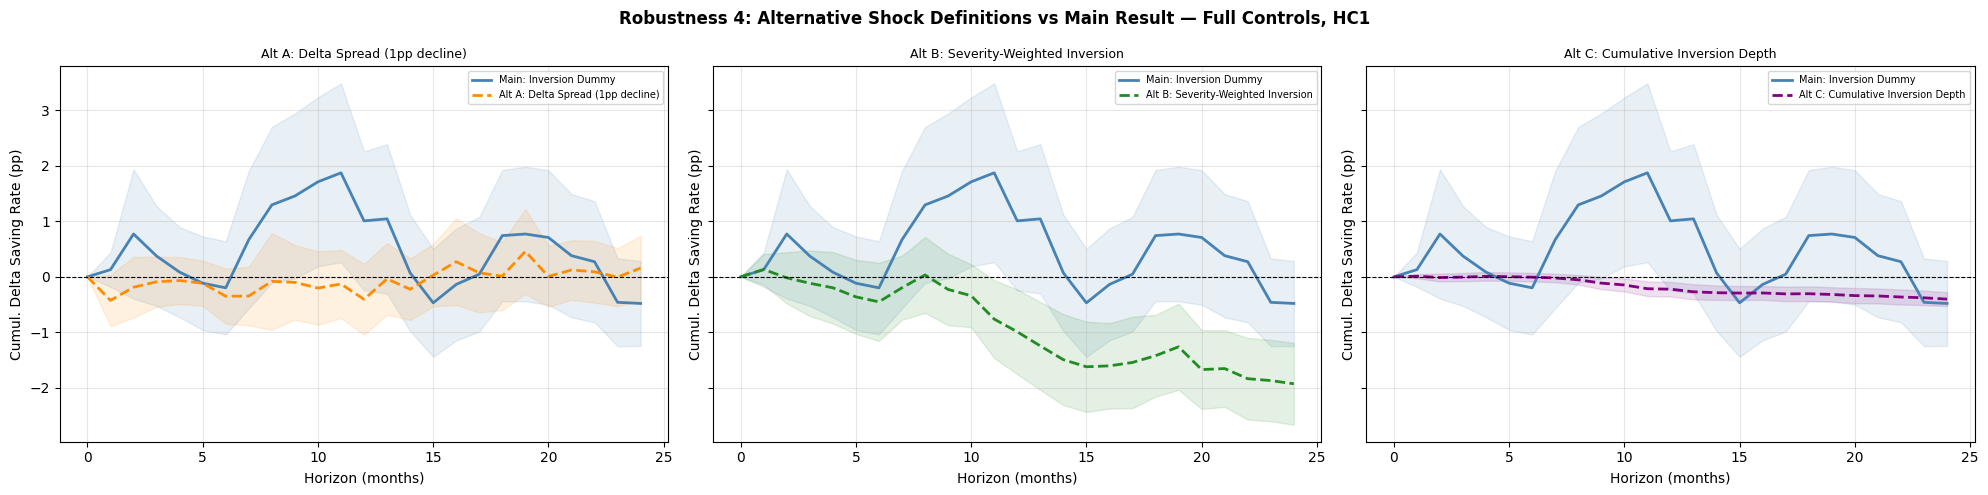


  Alternative Shock Summary — Coefficient at h=10
  * = significant at 10% level (90% CI excludes zero)
                            h=10 coef  ci_low  ci_high sig (90%)
Shock                                                           
Main: Inversion Dummy           1.711   0.189    3.233         *
Alt A: Delta Spread (-1pp)     -0.202  -0.863    0.459          
Alt B: Severity-Weighted       -0.341  -0.908    0.227          
Alt C: Cumulative Depth        -0.147  -0.264   -0.029         *


In [24]:
##############################################################################
# ROBUSTNESS 4 — Alternative Shock Definitions
#
# Tests whether results are driven by the specific shock definition.
# Three alternatives to the main inversion dummy:
#
#   Alt A: First difference of T10Y3M  (change in spread, not level)
#          Captures: "spread narrowed by X pp this month"
#
#   Alt B: Severity-weighted dummy
#          D_inversion × |T10Y3M|  — deeper inversions get higher weight
#          Captures: not just whether inverted, but how inverted
#
#   Alt C: Cumulative inversion depth
#          Rolling 6-month sum of negative T10Y3M values
#          Captures: sustained inversions matter more than brief ones
#
# All compared against the main result (Model 1: HC1, Full Sample)
##############################################################################

import statsmodels.api as sm

avail_outlier = [c for c in outlier_controls if c in df_lp.columns]

# --- Build alternative shock variables ---
df_lp_alt = df_lp.copy()

# Alt A: first difference of T10Y3M
df_lp_alt["d_T10Y3M"] = df_lp_alt["T10Y3M"].diff()

# Alt B: severity-weighted dummy (depth of inversion × dummy)
df_lp_alt["D_inv_severity"] = df_lp_alt["D_inversion"] * df_lp_alt["T10Y3M"].abs()

# Alt C: 6-month cumulative inversion depth
df_lp_alt["T10Y3M_neg"]  = df_lp_alt["T10Y3M"].clip(upper=0)
df_lp_alt["D_inv_cumul"] = df_lp_alt["T10Y3M_neg"].rolling(6).sum().abs()

df_lp_alt = df_lp_alt.dropna().reset_index(drop=True)
print(f"Alternative shock dataset: {len(df_lp_alt)} observations")


def run_lp_altshock(data, shock_var, se_type="HC1", H=H, shock_scale=1):
    res = []
    avail_ol = [c for c in outlier_controls if c in data.columns]
    for h in range(0, H + 1):
        y    = data[f"y_h{h}"]
        cols = [c for c in [shock_var] + contemp_controls + policy_controls
                + avail_ol + lag_cols if c in data.columns]
        fit_kwargs = ({"cov_type": "HC1"} if se_type == "HC1"
                      else {"cov_type": "HAC", "cov_kwds": {"maxlags": h + 1}})
        try:
            m  = sm.OLS(y, sm.add_constant(data[cols])).fit(**fit_kwargs)
            ci = m.conf_int(alpha=0.10).loc[shock_var]
            res.append({"h": h,
                        "coef":    m.params[shock_var] * shock_scale,
                        "ci_low":  min(ci[0] * shock_scale, ci[1] * shock_scale),
                        "ci_high": max(ci[0] * shock_scale, ci[1] * shock_scale)})
        except Exception:
            res.append({"h": h, "coef": np.nan, "ci_low": np.nan, "ci_high": np.nan})
    return pd.DataFrame(res)


print("Running Alt A (first difference of spread)...")
irf_altA = run_lp_altshock(df_lp_alt, "d_T10Y3M",      shock_scale=-1)

print("Running Alt B (severity-weighted inversion)...")
irf_altB = run_lp_altshock(df_lp_alt, "D_inv_severity", shock_scale=1)

print("Running Alt C (cumulative inversion depth)...")
irf_altC = run_lp_altshock(df_lp_alt, "D_inv_cumul",    shock_scale=1)

print("Done.")

# --- Plot: main IRF vs three alternatives ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

alt_specs = [
    (irf_altA, "Alt A: Delta Spread (1pp decline)", "darkorange"),
    (irf_altB, "Alt B: Severity-Weighted Inversion", "forestgreen"),
    (irf_altC, "Alt C: Cumulative Inversion Depth",  "purple"),
]

for ax, (irf_alt, alt_label, alt_color) in zip(axes, alt_specs):
    ax.plot(irf1_m1["h"], irf1_m1["coef"],
            color="steelblue", linewidth=2, label="Main: Inversion Dummy")
    ax.fill_between(irf1_m1["h"], irf1_m1["ci_low"], irf1_m1["ci_high"],
                    alpha=0.12, color="steelblue")
    ax.plot(irf_alt["h"], irf_alt["coef"],
            color=alt_color, linewidth=2, linestyle="--", label=alt_label)
    ax.fill_between(irf_alt["h"], irf_alt["ci_low"], irf_alt["ci_high"],
                    alpha=0.12, color=alt_color)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(alt_label, fontsize=9)
    ax.set_xlabel("Horizon (months)")
    ax.set_ylabel("Cumul. Delta Saving Rate (pp)")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle("Robustness 4: Alternative Shock Definitions vs Main Result — Full Controls, HC1",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Summary table: peak coefficient at h=10 ---
print(f"\n{'='*65}")
print("  Alternative Shock Summary — Coefficient at h=10")
print(f"  * = significant at 10% level (90% CI excludes zero)")
print(f"{'='*65}")

rows_alt = []
for irf, label in [
    (irf1_m1,  "Main: Inversion Dummy"),
    (irf_altA, "Alt A: Delta Spread (-1pp)"),
    (irf_altB, "Alt B: Severity-Weighted"),
    (irf_altC, "Alt C: Cumulative Depth"),
]:
    r   = irf[irf["h"] == 10].iloc[0]
    sig = r["ci_low"] > 0 or r["ci_high"] < 0
    rows_alt.append({
        "Shock":      label,
        "h=10 coef":  round(r["coef"],    3),
        "ci_low":     round(r["ci_low"],  3),
        "ci_high":    round(r["ci_high"], 3),
        "sig (90%)":  "*" if sig else ""
    })

print(pd.DataFrame(rows_alt).set_index("Shock").to_string())

## 4. Quintile Analysis - Panel Data

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Check Inversion Years mapped correctly:
 year    Spread  Inversion
 2014  2.508333          0
 2015  2.083333          0
 2016  1.524167          0
 2017  1.399167          0
 2018  0.970833          0
 2019  0.083333          1
 2020  0.529167          1
 2021  1.398333          0
 2022  0.930000          1
 2023 -1.110833          1


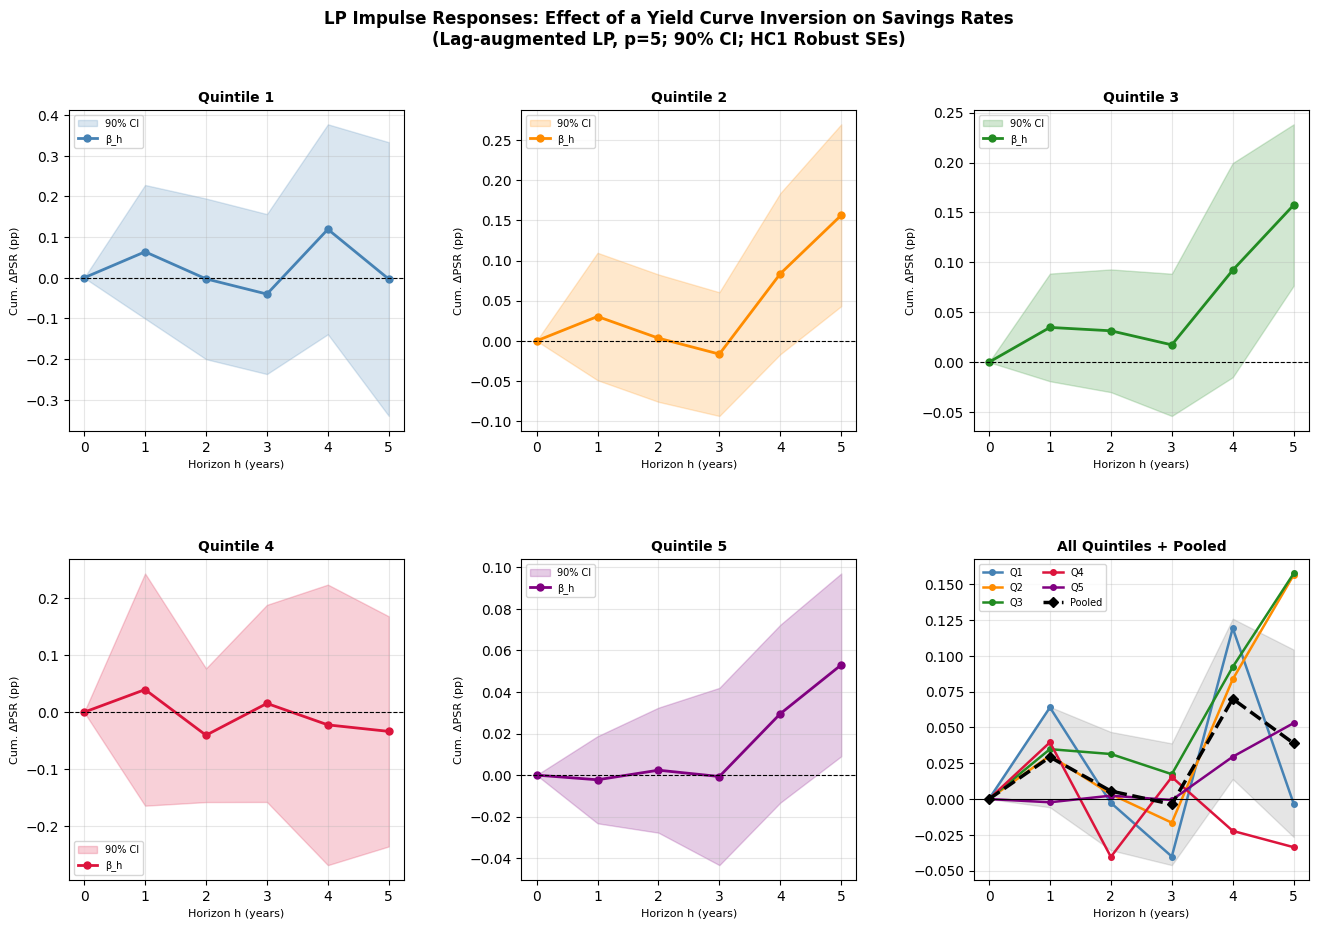

In [30]:
##############################################################################
# PANEL DATA — Step 2: Lag-Augmented Local Projections (LP-OLS)
#
# Specification (Jordà, 2005; Montiel Olea & Plagborg-Møller, 2021):
#
#   ΔPSR_{q,t+h} = α_h^{(q)} + β_h^{(q)} · Inversion_t + γ_h(L) · ΔPSR_{q,t} + ε_{q,t+h}
#
# where:
#   - h ∈ {0,1,...,H} is the forecast horizon (years)
#   - Inversion_t = Dummy variable (1 if 10Y-3M spread < 0, else 0)
#   - γ_h(L) · ΔPSR_{q,t} = p lag-augmented lags of ΔPSR_{q,t}
#   - SE: White Heteroskedasticity-Robust (HC1) for each quintile regression
##############################################################################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION A & B: Load Data, Create Panel, and Merge Spread
# ─────────────────────────────────────────────────────────────────────────────

data_path = "/content/drive/MyDrive/Maestría en economía /Tesis/Tesis Maestría/2026/input"

# --- Load 10-Year and 3-Month Treasury ---
gs10 = pd.read_csv(data_path + "/GS10.csv")
gs10.columns = ["date", "GS10"]
gs10["date"] = pd.to_datetime(gs10["date"])
gs10["year"] = gs10["date"].dt.year
gs10["GS10"] = pd.to_numeric(gs10["GS10"], errors="coerce")

tb3ms = pd.read_csv(data_path + "/TB3MS.csv")
tb3ms.columns = ["date", "TB3MS"]
tb3ms["date"] = pd.to_datetime(tb3ms["date"])
tb3ms["year"] = tb3ms["date"].dt.year
tb3ms["TB3MS"] = pd.to_numeric(tb3ms["TB3MS"], errors="coerce")

# --- FIX: Compute MONTHLY spread to detect inversions accurately ---
monthly_df = gs10.merge(tb3ms, on=["date", "year"], how="inner")
monthly_df["Spread_Monthly"] = monthly_df["GS10"] - monthly_df["TB3MS"]

# If the spread drops below 0 in ANY month of the year, mark the year as an Inversion (1)
inversion_years = monthly_df.groupby("year")["Spread_Monthly"].min().reset_index()
inversion_years["Inversion"] = (inversion_years["Spread_Monthly"] < 0).astype(int)

# --- Annual averages for the continuous spread (just for records) ---
gs10_ann  = gs10.groupby("year")["GS10"].mean().reset_index()
tb3ms_ann = tb3ms.groupby("year")["TB3MS"].mean().reset_index()

spread_df = gs10_ann.merge(tb3ms_ann, on="year", how="inner")
spread_df["Spread"] = spread_df["GS10"] - spread_df["TB3MS"]

# Merge the accurately calculated Inversion dummy into the annual spread dataframe
spread_df = spread_df.merge(inversion_years[["year", "Inversion"]], on="year", how="inner")

# --- Load Quintile Data and Reshape ---
df_raw = pd.read_csv(data_path + "/quintile_data.csv")
savings_cols = [col for col in df_raw.columns if "savings_rate" in col]
df_savings = df_raw[["Year"] + savings_cols]

df_panel = df_savings.melt(id_vars=["Year"],
                           value_vars=savings_cols,
                           var_name="quintile_str",
                           value_name="PSR")

df_panel["quintile"] = df_panel["quintile_str"].str.extract(r'q(\d)_').astype(int)
df_panel.rename(columns={"Year": "year"}, inplace=True)
df_panel = df_panel[["year", "quintile", "PSR"]].sort_values(["quintile", "year"]).reset_index(drop=True)
df_panel["PSR"] = pd.to_numeric(df_panel["PSR"], errors="coerce")

# --- Merge and Difference ---
# Now we merge both Spread and our proper Inversion dummy onto the panel
df_lp = df_panel.merge(spread_df[["year", "Spread", "Inversion"]], on="year", how="left")
df_lp["dPSR"] = df_lp.groupby("quintile")["PSR"].diff()

print("Check Inversion Years mapped correctly:")
print(df_lp[df_lp["quintile"] == 1][["year", "Spread", "Inversion"]].tail(10).to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# SECTION C: Construct LP regressors — lag augmentation
# ─────────────────────────────────────────────────────────────────────────────

MAX_H      = 5
N_LAGS     = MAX_H
ALPHA      = 0.10

for lag in range(1, N_LAGS + 1):
    df_lp[f"dPSR_L{lag}"] = df_lp.groupby("quintile")["dPSR"].shift(lag)

# ─────────────────────────────────────────────────────────────────────────────
# SECTION D: Local Projection Engine (HC1 Robust SEs)
# ─────────────────────────────────────────────────────────────────────────────

def run_lp_ols_robust(data, y_col, x_col, lag_cols, alpha=0.10):
    """
    Runs a clean LP for a single time series using White (HC1) Robust SEs.
    Avoids small-cluster matrix singularity issues entirely.
    """
    cols_needed = [y_col, x_col] + lag_cols
    sub = data[cols_needed].dropna()

    if len(sub) < 20:
        return None

    # X Matrix: Constant + Dummy + Lags
    X = pd.concat([
        pd.Series(1.0, index=sub.index, name="const"),
        sub[x_col],
        sub[lag_cols]
    ], axis=1).astype(float)

    y = sub[y_col].astype(float)

    Xmat = X.values
    yvec = y.values
    XtX_inv = np.linalg.pinv(Xmat.T @ Xmat)
    beta    = XtX_inv @ (Xmat.T @ yvec)
    resid   = yvec - Xmat @ beta

    n, k = Xmat.shape

    # White HC1 Heteroskedasticity-Robust Covariance Matrix
    meat = (Xmat * resid[:, None]).T @ (Xmat * resid[:, None])
    correction = n / (n - k)
    V_cov = correction * XtX_inv @ meat @ XtX_inv
    se_cov = np.sqrt(np.diag(V_cov))

    # Extract Shock Coefficient (index 1)
    idx = 1
    coef_val = beta[idx]
    se_val   = se_cov[idx]

    df_t   = n - k
    t_stat = coef_val / se_val if se_val > 0 else np.nan
    p_val  = 2 * stats.t.sf(abs(t_stat), df=df_t) if not np.isnan(t_stat) else np.nan
    t_crit = stats.t.ppf(1 - alpha / 2, df=df_t)

    return {
        "coef":  coef_val,
        "se":    se_val,
        "t_stat": t_stat,
        "p_val":  p_val,
        "ci_lo":  coef_val - t_crit * se_val,
        "ci_hi":  coef_val + t_crit * se_val,
        "nobs":   len(sub)
    }

# ── Main LP loop ─────────────────────────────────────────────────────────────

lag_cols = [f"dPSR_L{lag}" for lag in range(1, N_LAGS + 1)]
results_lp = {}

# 1. Run Quintile by Quintile
for q_num in range(1, 6):
    q_label = f"Q{q_num}"
    horizon_res = []

    for h in range(0, MAX_H + 1):
        temp = df_lp.copy()
        temp[f"cum_dPSR_h{h}"] = temp.groupby("quintile")["PSR"].shift(-h).values - temp["PSR"].values

        # Isolate just this quintile's time series
        sub_q = temp[temp["quintile"] == q_num].copy()

        res = run_lp_ols_robust(
            data     = sub_q,
            y_col    = f"cum_dPSR_h{h}",
            x_col    = "Inversion",    # <--- Changed from "Spread" to "Inversion"
            lag_cols = lag_cols,
            alpha    = ALPHA
        )
        if res:
            res["horizon"] = h
            horizon_res.append(res)

    results_lp[q_label] = pd.DataFrame(horizon_res).set_index("horizon")

# 2. Run Pooled (Average) Effect
pooled_res = []
for h in range(0, MAX_H + 1):
    temp = df_lp.copy()
    temp[f"cum_dPSR_h{h}"] = temp.groupby("quintile")["PSR"].shift(-h).values - temp["PSR"].values

    # Simple pooled average (no interactions, treating all data as one series)
    res = run_lp_ols_robust(
        data     = temp,
        y_col    = f"cum_dPSR_h{h}",
        x_col    = "Inversion",    # <--- Changed from "Spread" to "Inversion"
        lag_cols = lag_cols,
        alpha    = ALPHA
    )
    if res:
        res["horizon"] = h
        pooled_res.append(res)

results_lp["Pooled"] = pd.DataFrame(pooled_res).set_index("horizon")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION E & F: Print and Plot Results
# ─────────────────────────────────────────────────────────────────────────────

colors_q   = ["steelblue","darkorange","forestgreen","crimson","purple"]
horizons   = list(range(0, MAX_H + 1))
fig        = plt.figure(figsize=(16, 10))
gs_layout  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Individual quintile IRFs ──────────────────────────────────────────────────
for idx, (q_num, color) in enumerate(zip(range(1, 6), colors_q)):
    q_label = f"Q{q_num}"
    ax      = fig.add_subplot(gs_layout[idx // 3, idx % 3])
    df_res  = results_lp[q_label]

    ax.fill_between(df_res.index, df_res["ci_lo"], df_res["ci_hi"], alpha=0.20, color=color, label=f"{(1-ALPHA)*100:.0f}% CI")
    ax.plot(df_res.index, df_res["coef"], color=color, linewidth=2.0, marker="o", markersize=5, label="β_h")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

    ax.set_title(f"Quintile {q_num}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Horizon h (years)", fontsize=8)
    ax.set_ylabel("Cum. ΔPSR (pp)", fontsize=8)
    ax.set_xticks(horizons)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

# ── Pooled IRF ───────────────────────────────────────────────────────────────
ax_pool = fig.add_subplot(gs_layout[1, 2])
for q_num, color in zip(range(1, 6), colors_q):
    q_label = f"Q{q_num}"
    df_res  = results_lp[q_label]
    ax_pool.plot(df_res.index, df_res["coef"], color=color, linewidth=1.8, marker="o", markersize=4, label=q_label)

df_pooled = results_lp["Pooled"]
ax_pool.plot(df_pooled.index, df_pooled["coef"], color="black", linewidth=2.5, marker="D", markersize=5, linestyle="--", label="Pooled")
ax_pool.fill_between(df_pooled.index, df_pooled["ci_lo"], df_pooled["ci_hi"], alpha=0.10, color="black")
ax_pool.axhline(0, color="black", linewidth=0.8, linestyle="-")
ax_pool.set_title("All Quintiles + Pooled", fontsize=10, fontweight="bold")
ax_pool.set_xlabel("Horizon h (years)", fontsize=8)
ax_pool.set_xticks(horizons)
ax_pool.legend(fontsize=7, ncol=2)
ax_pool.grid(alpha=0.3)

fig.suptitle(
    "LP Impulse Responses: Effect of a Yield Curve Inversion on Savings Rates\n"
    f"(Lag-augmented LP, p={N_LAGS}; {(1-ALPHA)*100:.0f}% CI; HC1 Robust SEs)",
    fontsize=12, fontweight="bold"
)
plt.show()

## 5. Results Exports